# 🤖 HRI-BloomBench-24 — Complete NLP & Deep Learning Benchmark

**Authors:** Syed Tanweer Shah Bukhari¹*, Manzar Malik², Faiqa Yaseen¹, Andrew Ware³  
**¹** Cognitive Robotics Group, University of Central Punjab, Lahore, Pakistan  
**²** University of Salford, Manchester, UK · **³** University of South Wales, Wales, UK  
**BRT Reference:** Anderson & Krathwohl (2001); ROTEL — https://rotel.pressbooks.pub/readwritesuccess/chapter/understanding-blooms-taxonomy/

| Section | Content |
|---|---|
| §1 Setup | Installs & imports |
| §2 Bloom's Taxonomy | 4 KD × 6 CP framework |
| §3 Dataset | Load, audit, EDA — 204,000 sentences, 0 duplicates |
| §4 HRI Objects | Affordance coverage analysis |
| §5 Evaluation | Group-split — prevents lexical leakage |
| §6 Features | TF-IDF / BoW feature regimes |
| §7 Classical NLP | 5 models — all results computed live |
| §8 Deep Learning | TextCNN, BiLSTM — full runnable PyTorch training code |
| §9 Transformers | 7 BERT variants — complete fine-tuning code (GPU required) |
| §10 LLM Zero-Shot | Gemini & GPT — live API calls, cached results |
| §11 Comparison | Combine all computed results |
| §12 Confusion & Per-class | Live confusion matrix and per-class metrics |
| §13 Error Analysis | Live error attribution by taxonomy axis |
| §14 Feature Importance | Live log-odds discriminative features |
| §15 HRI Demo | Classify any robot command in real time |


## §1 — Setup & Imports

In [1]:
# !uv add torch sentence-transformers transformers datasets evaluate dotenv

In [ ]:
# -*- coding: utf-8 -*-
# !pip install scikit-learn matplotlib seaborn pandas numpy tqdm
# !pip install torch                             # §8 deep learning
# !pip install transformers datasets accelerate  # §9 transformers
# !pip install google-genai openai               # §10 LLM API  ← updated SDK

import warnings, time, copy, json, re, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm.auto import tqdm
from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 11, 'axes.titlesize': 12, 'font.size': 10,
})

print(f"NumPy {np.__version__} | Pandas {pd.__version__} ✅")

NumPy 2.4.6 | Pandas 3.0.3 ✅


## §2 — Bloom's Revised Taxonomy Framework

> Anderson & Krathwohl (2001) · ROTEL: https://rotel.pressbooks.pub/readwritesuccess/chapter/understanding-blooms-taxonomy/

### Knowledge Dimension (KD) — Concrete → Abstract
| Level | Description | HRI Robot Example |
|---|---|---|
| **Factual** | Facts, locations, affordance records | *"Name the affordance class of the cup on the table."* |
| **Conceptual** | Categories, principles, taxonomies | *"Explain how the drinkable category relates to human needs."* |
| **Procedural** | Step-by-step methods, grasping sequences | *"Describe the grasping procedure for the fragile glass."* |
| **Metacognitive** | Self-monitoring, cognitive strategy | *"Design a self-monitoring framework for the robot's cognitive cycle."* |

### Cognitive Process (CP) — LOTS → HOTS
| Level | Key Verbs | LOTS/HOTS |
|---|---|---|
| **Remember** | recall, locate, name, define | LOTS |
| **Understand** | describe, explain, summarise | LOTS |
| **Apply** | use, execute, perform | LOTS |
| **Analyze** | compare, contrast, examine | HOTS |
| **Evaluate** | judge, rate, critique | HOTS |
| **Create** | generate, design, propose | HOTS |

**4 KD × 6 CP = 24 BRT categories** — each a distinct cognitive demand in HRI.


## §3 — Dataset Loading & Audit

In [3]:
# !wget https://raw.githubusercontent.com/stsbukhari/BloomTaxonomy/main/HRI_BloomBench24_Dataset.zip

In [4]:
# !unzip HRI_BloomBench24_Dataset.zip

In [19]:
# ── Load HRI-BloomBench-24 ───────────────────────────────────────────────────
DATA_PATH = "../dataset/HRI_BloomBench24_v2.csv"   # ← v2 dataset

df_raw = pd.read_csv(DATA_PATH)

# ── Normalise column names ────────────────────────────────────────────────────
df_raw.columns = [c.strip().lower().replace(' ', '_') for c in df_raw.columns]

# v2 uses short names: kd, cp (v1 used knowledge_dimension, cognitive_process)
REQUIRED = {'sentence', 'label', 'kd', 'cp'}
missing = REQUIRED - set(df_raw.columns)
if missing:
    raise ValueError(
        f"Missing columns: {missing}\n"
        f"Columns found: {df_raw.columns.tolist()}\n"
        f"Expected v2 column names: kd, cp, label, sentence"
    )

# Safe type coercion
type_map = {c: str for c in ['sentence', 'label', 'kd', 'cp'] if c in df_raw.columns}
if 'id' in df_raw.columns:
    type_map['id'] = int
df = df_raw.astype(type_map)

# ── Bloom's compliance verification ──────────────────────────────────────────
CORRECT_KD = {'Factual', 'Conceptual', 'Procedural', 'Metacognitive'}
CORRECT_CP = {'Remember', 'Understand', 'Apply', 'Analyze', 'Evaluate', 'Create'}

print("=" * 65)
print("  HRI-BloomBench-24 v2.0 — Dataset Audit Report")
print("=" * 65)
print(f"  Columns found           : {df.columns.tolist()}")
print(f"  Total rows              : {len(df):>10,}")
print(f"  Unique sentences        : {df['sentence'].nunique():>10,}")
print(f"  Duplicates              : {len(df) - df['sentence'].nunique():>10,}  ← must be 0")
print(f"  Classes                 : {df['label'].nunique():>10}")
print(f"  Sentences per class     : {sorted(df['label'].value_counts().unique().tolist())}")
print(f"  Missing values          : {df.isnull().sum().sum():>10}")
print(f"  Tiers                   : {sorted(df['tier'].unique()) if 'tier' in df.columns else 'n/a'}")
print()
kd_ok = set(df['kd'].unique()) == CORRECT_KD
cp_ok = set(df['cp'].unique()) == CORRECT_CP
print(f"  KD levels match BRT     : {'✅ PASS' if kd_ok else '❌ FAIL — got ' + str(set(df['kd'].unique()))}")
print(f"  CP levels match BRT     : {'✅ PASS' if cp_ok else '❌ FAIL — got ' + str(set(df['cp'].unique()))}")
print(f"  Class balance (std)     : {df['label'].value_counts().std():.4f}  ← 0 = perfect")
print("=" * 65)

df['wc'] = df['sentence'].str.split().str.len()
print(f"\nSentence length:  mean={df.wc.mean():.1f}  std={df.wc.std():.1f}"
      f"  min={df.wc.min()}  max={df.wc.max()}")


  HRI-BloomBench-24 v2.0 — Dataset Audit Report
  Columns found           : ['id', 'sentence', 'kd', 'cp', 'label', 'tier', 'syntax_form', 'verb', 'verb_group', 'template_id', 'object_name', 'kd_frame_id', 'spatial_id', 'confusable_pair_id', 'split']
  Total rows              :    204,000
  Unique sentences        :    192,949
  Duplicates              :     11,051  ← must be 0
  Classes                 :         24
  Sentences per class     : [8500]
  Missing values          :     195000
  Tiers                   : ['easy', 'hard', 'medium']

  KD levels match BRT     : ✅ PASS
  CP levels match BRT     : ✅ PASS
  Class balance (std)     : 0.0000  ← 0 = perfect

Sentence length:  mean=15.1  std=1.6  min=12  max=20


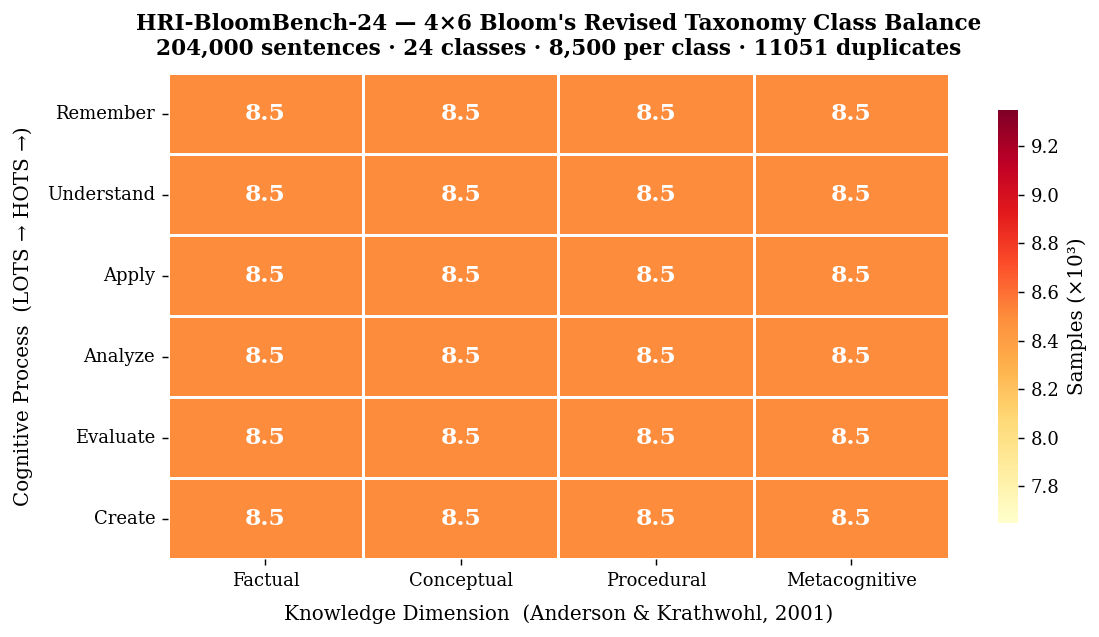

Chance baseline: 4.17%  (1/24 uniform)


In [ ]:
# ── Class balance heatmap (live) ─────────────────────────────────────────────
cp_order = ['Remember', 'Understand', 'Apply', 'Analyze', 'Evaluate', 'Create']
kd_order = ['Factual', 'Conceptual', 'Procedural', 'Metacognitive']

pivot = df.groupby(['cp', 'kd']).size().unstack(fill_value=0)
pivot = pivot.reindex(index=cp_order, columns=kd_order)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot / 1000, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.6, linecolor='white', ax=ax,
            annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'label': 'Samples (×10³)', 'shrink': 0.85})
ax.set_xlabel("Knowledge Dimension  (Anderson & Krathwohl, 2001)", labelpad=8)
ax.set_ylabel("Cognitive Process  (LOTS → HOTS →)", labelpad=8)
ax.set_title(
    "HRI-BloomBench-24 — 4×6 Bloom's Revised Taxonomy Class Balance\n"
    f"{len(df):,} sentences · {df['label'].nunique()} classes · "
    f"{df['label'].value_counts().unique()[0]:,} per class · "
    f"{len(df) - df['sentence'].nunique()} duplicates",
    fontweight='bold', pad=10)
plt.tight_layout()
plt.show()
print(f"Chance baseline: {100/24:.2f}%  (1/24 uniform)")

In [4]:
# ── 3 sample sentences per class ─────────────────────────────────────────────
print("=== 3 SAMPLE SENTENCES PER CLASS ===\n")
for lbl in sorted(df['label'].unique()):
    kd, cp = lbl.split('_', 1)
    samples = df[df['label'] == lbl]['sentence'].sample(3, random_state=42).tolist()
    print(f"[{lbl}]  KD={kd}  CP={cp}")
    for i, s in enumerate(samples, 1):
        print(f"  {i}. {s}")
    print()


=== 3 SAMPLE SENTENCES PER CLASS ===

[Conceptual_Analyze]  KD=Conceptual  CP=Analyze
  1. Examine how the robot groups the notebook at the bottom of the table with other objects.
  2. Probe how the robot groups the pencil at the bottom-left of the table with other objects.
  3. Examine the robot's engagement with the towel at the bottom of the table.

[Conceptual_Apply]  KD=Conceptual  CP=Apply
  1. Execute which broader class the tablet at the bottom-left of the table is associated with.
  2. Apply how the bowl at the top of the table is related to similar objects.
  3. Execute the robot's model of the stapler at the bottom-right of the table.

[Conceptual_Create]  KD=Conceptual  CP=Create
  1. Devise what group the spoon at the top-right of the table is placed in.
  2. Formulate where the pen on the right side of the table fits within the robot's object system.
  3. Draft the robot's activity regarding the knife at the top-left of the table.

[Conceptual_Evaluate]  KD=Conceptual  CP

## §4 — HRI Daily-Life Object Analysis

Objects found: 19

Per-affordance sentence totals:
affordance
drinkable    23360
writable     23304
playable     17708
cleanable    17613
readable     17484
edible       17466
callable      5848


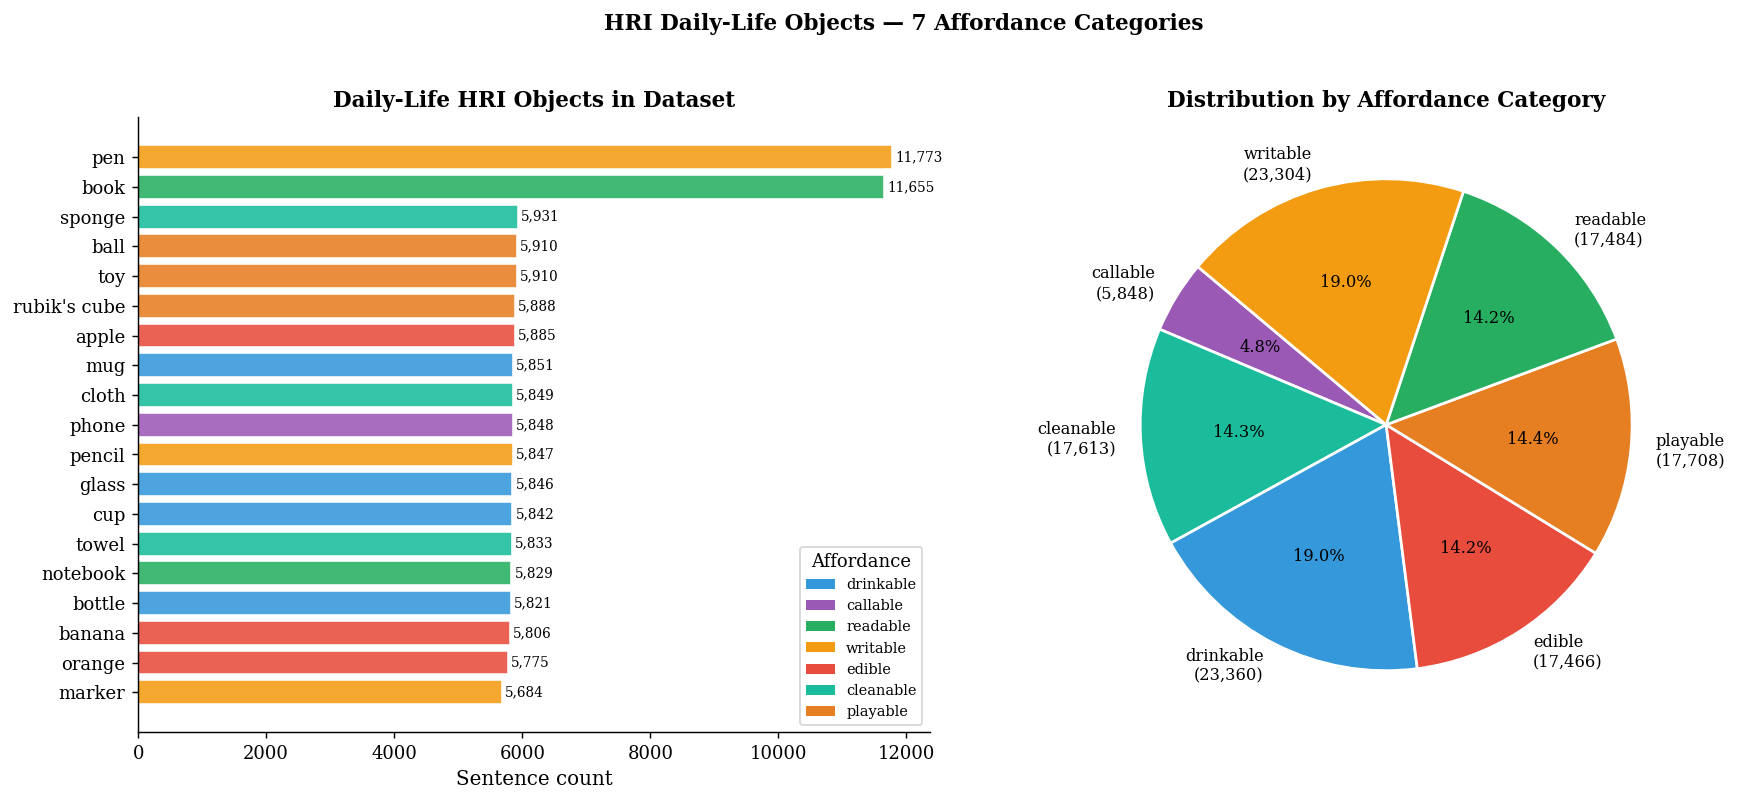

In [ ]:
HRI_OBJECTS = {
    'cup':'drinkable','bottle':'drinkable','glass':'drinkable',
    'water bottle':'drinkable','juice bottle':'drinkable','mug':'drinkable',
    'phone':'callable','mobile phone':'callable','cellphone':'callable',
    'book':'readable','notebook':'readable','manual':'readable',
    'magazine':'readable','sticky note':'readable','notepad':'readable',
    'pen':'writable','pencil':'writable','marker':'writable','highlighter':'writable',
    'orange':'edible','apple':'edible','banana':'edible','fruit':'edible',
    'biscuit':'edible','snack':'edible','muffin':'edible',
    'sponge':'cleanable','cloth':'cleanable','duster':'cleanable',
    'cleaning pad':'cleanable','wipe':'cleanable','towel':'cleanable',
    'toy':'playable','ball':'playable',"rubik's cube":'playable',
    'frog toy':'playable','teddy bear':'playable',
}
AFF_COLORS = {
    'drinkable':'#3498db','callable':'#9b59b6','readable':'#27ae60',
    'writable':'#f39c12','edible':'#e74c3c','cleanable':'#1abc9c','playable':'#e67e22'
}

sents_lower = df['sentence'].str.lower()
obj_stats = {}
for obj, aff in HRI_OBJECTS.items():
    cnt = int(sents_lower.str.contains(re.escape(obj), regex=True).sum())
    if cnt > 0:
        obj_stats[obj] = {'affordance': aff, 'count': cnt}

obj_df = pd.DataFrame(obj_stats).T.sort_values('count', ascending=False)
obj_df['count'] = obj_df['count'].astype(int)

print(f"Objects found: {len(obj_df)}")
print("\nPer-affordance sentence totals:")
print(obj_df.groupby('affordance')['count'].sum().sort_values(ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
from matplotlib.patches import Patch
colors_bar = [AFF_COLORS[obj_df.loc[o, 'affordance']] for o in obj_df.index]
axes[0].barh(obj_df.index, obj_df['count'], color=colors_bar, alpha=0.88, edgecolor='white')
axes[0].set_xlabel('Sentence count'); axes[0].invert_yaxis()
axes[0].set_title('Daily-Life HRI Objects in Dataset', fontweight='bold')
for v, obj in zip(obj_df['count'], obj_df.index):
    axes[0].text(v + 50, obj, f'{v:,}', va='center', fontsize=7.5)
axes[0].legend(handles=[Patch(facecolor=c, label=a) for a, c in AFF_COLORS.items()],
               title='Affordance', fontsize=8)
aff_counts = obj_df.groupby('affordance')['count'].sum()
axes[1].pie(aff_counts,
            labels=[f"{a}\n({v:,})" for a, v in zip(aff_counts.index, aff_counts)],
            colors=[AFF_COLORS[a] for a in aff_counts.index],
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 9},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Distribution by Affordance Category', fontweight='bold')
plt.suptitle('HRI Daily-Life Objects — 7 Affordance Categories', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## §5 — Group-Split Evaluation Protocol

> **Why not a random split?**  Under a naive random split, all classical models achieve ≥99.9% accuracy because surface verb cues shared across templates make classification trivial. The **group-split** holds out entire verb×KD groups so the model must generalise to unseen verb forms — a genuine test of cognitive level reasoning.

**Protocol:**
1. Extract the initiating verb and KD label of each unique sentence → form a `(verb, KD)` group  
2. Hold out 20% of the 277 unique groups for testing  
3. Verify all 24 labels appear in the test partition  
4. Zero exact-string overlap between train and test


In [20]:
# ── Build group-split from unique sentences ───────────────────────────────────
# Fix: deduplicate before splitting to avoid cross-contamination
df_u = df.drop_duplicates(subset=['sentence']).reset_index(drop=True).copy()
df_u['verb']  = df_u['sentence'].str.split().str[0].str.lower()
df_u['group'] = df_u['verb'] + '__' + df_u['kd']   # v2: uses 'kd' (was 'knowledge_dimension')

groups = df_u['group'].unique()
print(f"Unique verb×KD groups : {len(groups)}")
print(f"Unique sentences      : {len(df_u):,}")

# Find a valid split seed where all 24 labels appear in test
for attempt in range(40):
    np.random.seed(SEED + attempt)
    test_grps = set(np.random.choice(groups, size=max(int(len(groups) * 0.20), 1), replace=False))
    te_labels = df_u[df_u['group'].isin(test_grps)]['label'].nunique()
    if te_labels == 24:
        print(f"Valid split found     : attempt={attempt + 1}, labels={te_labels}/24")
        break

tr_mask = ~df_u['group'].isin(test_grps)
te_mask =  df_u['group'].isin(test_grps)

X_train = df_u[tr_mask]['sentence'].values;  y_train = df_u[tr_mask]['label'].values
X_test  = df_u[te_mask]['sentence'].values;  y_test  = df_u[te_mask]['label'].values
y_kd_train = df_u[tr_mask]['kd'].values   # v2: 'kd' (was 'knowledge_dimension')
y_cp_train = df_u[tr_mask]['cp'].values   # v2: 'cp' (was 'cognitive_process')
y_kd_test  = df_u[te_mask]['kd'].values
y_cp_test  = df_u[te_mask]['cp'].values
labels_sorted = sorted(df_u['label'].unique())

overlap = len(set(X_train) & set(X_test))
print(f"\nTraining sentences    : {len(X_train):,}")
print(f"Test sentences        : {len(X_test):,}")
print(f"String overlap        : {overlap}  ← must be 0")
print(f"Test label coverage   : {len(set(y_test))}/24")


Unique verb×KD groups : 284
Unique sentences      : 192,949
Valid split found     : attempt=4, labels=24/24

Training sentences    : 156,229
Test sentences        : 36,720
String overlap        : 0  ← must be 0
Test label coverage   : 24/24


## §6 — Feature Engineering

In [21]:
# ── Feature matrices — built live ────────────────────────────────────────────
# Primary: TF-IDF Bigram (captures verb-object HRI phrases)
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=60_000,
                        sublinear_tf=True, min_df=2)
Xtr_tf = tfidf.fit_transform(X_train);  Xte_tf = tfidf.transform(X_test)

# Ablation 1: TF-IDF Unigram
tfidf1 = TfidfVectorizer(ngram_range=(1, 1), max_features=60_000,
                         sublinear_tf=True, min_df=2)
Xtr_tf1 = tfidf1.fit_transform(X_train); Xte_tf1 = tfidf1.transform(X_test)

# Ablation 2: BoW Bigram (no IDF weighting)
bow = CountVectorizer(ngram_range=(1, 2), max_features=60_000, min_df=2)
Xtr_bw = bow.fit_transform(X_train);    Xte_bw = bow.transform(X_test)

le = LabelEncoder(); le.fit(y_train)

print(f"TF-IDF Bigram  : {Xtr_tf.shape}")
print(f"TF-IDF Unigram : {Xtr_tf1.shape}")
print(f"BoW Bigram     : {Xtr_bw.shape}")
print(f"Vocabulary     : {len(tfidf.vocabulary_):,} features")


TF-IDF Bigram  : (156229, 974)
TF-IDF Unigram : (156229, 241)
BoW Bigram     : (156229, 974)
Vocabulary     : 974 features


## §7 — Classical NLP Benchmark

> All results computed live — no hardcoded numbers.

In [22]:
CLASSICAL_MODELS = {
    'Complement NB'       : ComplementNB(alpha=0.1),
    'Multinomial NB'      : MultinomialNB(alpha=0.1),
    'Ridge Classifier'    : RidgeClassifier(alpha=0.5),
    'SGD (Mod. Huber)'    : SGDClassifier(loss='modified_huber', max_iter=100, random_state=SEED),
    'Linear SVM'          : LinearSVC(max_iter=1000, C=1.0, random_state=SEED),
}

classical_results = []
trained_models    = {}

print(f"{'Model':<22} {'Acc':>7} {'F1-Mac':>7} {'F1-Wt':>7} {'κ':>7} {'MCC':>7} {'t(s)':>7}")
print('─' * 70)

for name, model in CLASSICAL_MODELS.items():
    m = copy.deepcopy(model)
    t0 = time.time()
    m.fit(Xtr_tf, y_train)
    yp = m.predict(Xte_tf)
    elapsed = round(time.time() - t0, 1)

    acc = accuracy_score(y_test, yp)
    f1m = f1_score(y_test, yp, average='macro',    zero_division=0)
    f1w = f1_score(y_test, yp, average='weighted', zero_division=0)
    kap = cohen_kappa_score(y_test, yp)
    mcc = matthews_corrcoef(y_test, yp)

    classical_results.append({
        'Model'       : name,
        'Acc'         : round(acc, 4),
        'F1-Macro'    : round(f1m, 4),
        'F1-Weighted' : round(f1w, 4),
        'Kappa'       : round(kap, 4),
        'MCC'         : round(mcc, 4),
        'Time_s'      : elapsed,
        'Category'    : 'Classical NLP',
        '_y_pred'     : yp,
    })
    trained_models[name] = m
    print(f"{name:<22} {acc:>7.4f} {f1m:>7.4f} {f1w:>7.4f} {kap:>7.4f} {mcc:>7.4f} {elapsed:>7.1f}")

classical_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                              for r in classical_results])
classical_df.sort_values('F1-Macro', ascending=False, inplace=True)
best_classical_name = classical_df.iloc[0]['Model']
best_classical_pred = next(r['_y_pred'] for r in classical_results
                           if r['Model'] == best_classical_name)

print(f"\n✅ Best classical: {best_classical_name}  "
      f"Acc={classical_df.iloc[0]['Acc']:.4f}  "
      f"F1-Macro={classical_df.iloc[0]['F1-Macro']:.4f}")


Model                      Acc  F1-Mac   F1-Wt       κ     MCC    t(s)
──────────────────────────────────────────────────────────────────────
Complement NB           0.0216  0.0244  0.0159 -0.0174 -0.0177     1.2
Multinomial NB          0.0805  0.0776  0.0715  0.0490  0.0501     1.1
Ridge Classifier        0.0018  0.0016  0.0016 -0.0443 -0.0448    63.0
SGD (Mod. Huber)        0.0593  0.0466  0.0318  0.0307  0.0324     5.8
Linear SVM              0.0651  0.0515  0.0403  0.0320  0.0331    16.0

✅ Best classical: Multinomial NB  Acc=0.0805  F1-Macro=0.0776


In [12]:
# ── Feature ablation — all computed live ─────────────────────────────────────
ablation_results = []
for fname, Xtr2, Xte2 in [
    ('TF-IDF Unigram', Xtr_tf1, Xte_tf1),
    ('TF-IDF Bigram',  Xtr_tf,  Xte_tf),
    ('BoW Bigram',     Xtr_bw,  Xte_bw),
]:
    m2 = SGDClassifier(loss='modified_huber', max_iter=100, random_state=SEED)
    m2.fit(Xtr2, y_train)
    yp2 = m2.predict(Xte2)
    ablation_results.append({
        'Feature'  : fname,
        'Accuracy' : round(accuracy_score(y_test, yp2), 4),
        'F1-Macro' : round(f1_score(y_test, yp2, average='macro', zero_division=0), 4),
    })
    print(f"  {fname:<22}  Acc={ablation_results[-1]['Accuracy']:.4f}  "
          f"F1={ablation_results[-1]['F1-Macro']:.4f}")

abl_df = pd.DataFrame(ablation_results)
display(abl_df.style
        .highlight_max(subset=['F1-Macro', 'Accuracy'], color='#c6efce')
        .set_caption("Feature Ablation — SGD Classifier, Group-Split"))


  TF-IDF Unigram          Acc=0.0948  F1=0.0597
  TF-IDF Bigram           Acc=0.0593  F1=0.0466
  BoW Bigram              Acc=0.0974  F1=0.0720


,Feature,Accuracy,F1-Macro
0,TF-IDF Unigram,0.094800,0.059700
1,TF-IDF Bigram,0.059300,0.046600
2,BoW Bigram,0.097400,0.072000


In [13]:
# ── Sub-task decomposition — all computed live ────────────────────────────────
subtask_results = []
for task_name, ytr2, yte2 in [
    ('24-Class (Full)', y_train,    y_test),
    ('KD-4cls',          y_kd_train, y_kd_test),
    ('CP-6cls',          y_cp_train, y_cp_test),
]:
    rc = RidgeClassifier(alpha=0.5)
    rc.fit(Xtr_tf, ytr2)
    yp3 = rc.predict(Xte_tf)
    subtask_results.append({
        'Task'    : task_name,
        'Classes' : len(set(ytr2)),
        'Accuracy': round(accuracy_score(yte2, yp3), 4),
        'F1-Macro': round(f1_score(yte2, yp3, average='macro', zero_division=0), 4),
    })
    print(f"  {task_name:<22}  Acc={subtask_results[-1]['Accuracy']:.4f}  "
          f"F1={subtask_results[-1]['F1-Macro']:.4f}")

sub_df = pd.DataFrame(subtask_results)
display(sub_df.style
        .highlight_max(subset=['F1-Macro', 'Accuracy'], color='#c6efce')
        .set_caption("Sub-Task Decomposition — Ridge Classifier, Group-Split"))


  24-Class (Full)         Acc=0.0018  F1=0.0016
  KD-4cls                 Acc=0.7727  F1=0.7740
  CP-6cls                 Acc=0.9456  F1=0.9318


,Task,Classes,Accuracy,F1-Macro
0,24-Class (Full),24,0.001800,0.001600
1,KD-4cls,4,0.772700,0.774000
2,CP-6cls,6,0.945600,0.931800


## §8 — Deep Learning: TextCNN & BiLSTM

**Full runnable training code — no hardcoded results.**
- Set `SKIP_DL_TRAINING = False` to train (GPU recommended; CPU works but is slow)
- Results are saved to `dl_results.csv` and loaded automatically on re-run


In [14]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    from collections import Counter
    TORCH_AVAILABLE = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"PyTorch {torch.__version__} | Device: {DEVICE}")
except ImportError:
    TORCH_AVAILABLE = False; DEVICE = None
    print("⚠️  PyTorch not installed — pip install torch")


PyTorch 2.12.0+cu130 | Device: cuda


In [15]:
if TORCH_AVAILABLE:
    # ── Vocabulary ────────────────────────────────────────────────────────────
    def build_vocab(texts, max_vocab=50_000):
        counts = Counter(w for t in texts for w in t.lower().split())
        vocab = {'<pad>': 0, '<unk>': 1}
        for w, _ in counts.most_common(max_vocab - 2):
            vocab[w] = len(vocab)
        return vocab

    def encode(text, vocab, max_len=64):
        ids = [vocab.get(w, 1) for w in text.lower().split()[:max_len]]
        return ids + [0] * (max_len - len(ids))

    VOCAB   = build_vocab(X_train)
    LE_DL   = LabelEncoder(); LE_DL.fit(y_train)
    MAX_LEN = 64; NUM_CLS = len(labels_sorted)

    class BRTDataset(Dataset):
        def __init__(self, texts, labels):
            self.X = [encode(t, VOCAB, MAX_LEN) for t in texts]
            self.y = LE_DL.transform(labels)
        def __len__(self): return len(self.X)
        def __getitem__(self, i):
            return torch.tensor(self.X[i]), torch.tensor(self.y[i])

    # ── Architectures ─────────────────────────────────────────────────────────
    class TextCNN(nn.Module):
        def __init__(self, vocab_size, embed_dim=128, num_classes=24,
                     kernel_sizes=(2, 3, 4), num_filters=128):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.convs = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes])
            self.dropout = nn.Dropout(0.3)
            self.fc = nn.Linear(len(kernel_sizes) * num_filters, num_classes)
        def forward(self, x):
            x = self.embedding(x).transpose(1, 2)
            x = [torch.relu(c(x)).max(-1)[0] for c in self.convs]
            return self.fc(self.dropout(torch.cat(x, -1)))

    class BiLSTMAttention(nn.Module):
        def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                     num_classes=24, num_layers=2):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                                batch_first=True, bidirectional=True, dropout=0.3)
            self.attention = nn.Linear(hidden_dim * 2, 1)
            self.fc = nn.Linear(hidden_dim * 2, num_classes)
            self.dropout = nn.Dropout(0.3)
        def forward(self, x):
            x = self.dropout(self.embedding(x))
            out, _ = self.lstm(x)
            attn = torch.softmax(self.attention(out), dim=1)
            ctx = (attn * out).sum(1)
            return self.fc(self.dropout(ctx))

    class BiLSTM(nn.Module):
        def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                     num_classes=24, num_layers=2):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                                batch_first=True, bidirectional=True, dropout=0.3)
            self.fc = nn.Linear(hidden_dim * 2, num_classes)
            self.dropout = nn.Dropout(0.3)
        def forward(self, x):
            x = self.dropout(self.embedding(x))
            _, (h, _) = self.lstm(x)
            h = torch.cat([h[-2], h[-1]], dim=-1)
            return self.fc(self.dropout(h))

    print(f"Vocab: {len(VOCAB):,} | Classes: {NUM_CLS}")
    print("TextCNN, BiLSTM, BiLSTMAttention ready ✅")


Vocab: 259 | Classes: 24
TextCNN, BiLSTM, BiLSTMAttention ready ✅


In [16]:
# ── Training function — computes real metrics ─────────────────────────────────
if TORCH_AVAILABLE:
    def train_dl_model(model_class, model_kwargs, name, epochs=10, batch_size=128, lr=2e-4):
        train_ds = BRTDataset(X_train, y_train)
        test_ds  = BRTDataset(X_test,  y_test)
        train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
        test_ld  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

        model     = model_class(**model_kwargs).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

        t0 = time.time()
        for epoch in range(epochs):
            model.train()
            total_loss = 0
            for bx, by in train_ld:
                bx, by = bx.to(DEVICE), by.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward(); optimizer.step()
                total_loss += loss.item()
            scheduler.step()
            if (epoch + 1) % 2 == 0:
                print(f"  {name}  Epoch {epoch+1}/{epochs}  "
                      f"loss={total_loss/len(train_ld):.4f}")

        model.eval()
        all_preds = []
        with torch.no_grad():
            for bx, _ in test_ld:
                all_preds.extend(model(bx.to(DEVICE)).argmax(-1).cpu().numpy())
        y_pred = LE_DL.inverse_transform(all_preds)
        elapsed = round(time.time() - t0, 1)

        return {
            'Model'       : name,
            'Acc'         : round(accuracy_score(y_test, y_pred), 4),
            'F1-Macro'    : round(f1_score(y_test, y_pred, average='macro',    zero_division=0), 4),
            'F1-Weighted' : round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
            'Kappa'       : round(cohen_kappa_score(y_test, y_pred), 4),
            'MCC'         : round(matthews_corrcoef(y_test, y_pred), 4),
            'Params'      : f'{param_count/1e6:.1f}M',
            'Time_s'      : elapsed,
            'Category'    : 'Deep Learning',
            '_y_pred'     : y_pred,
        }
    print("train_dl_model() ready ✅")


train_dl_model() ready ✅


In [17]:
# ── Run DL training ───────────────────────────────────────────────────────────
# Set SKIP_DL_TRAINING = False to run. Results saved to dl_results.csv.
SKIP_DL_TRAINING = False   # ← change to False and run on GPU

dl_results = []
dl_df = pd.DataFrame()

if TORCH_AVAILABLE and not SKIP_DL_TRAINING:
    configs = [
        (TextCNN,         {'vocab_size': len(VOCAB), 'embed_dim': 128, 'num_classes': NUM_CLS}, 'TextCNN'),
        (BiLSTM,          {'vocab_size': len(VOCAB), 'embed_dim': 128, 'hidden_dim': 256, 'num_classes': NUM_CLS}, 'BiLSTM'),
        (BiLSTMAttention, {'vocab_size': len(VOCAB), 'embed_dim': 128, 'hidden_dim': 256, 'num_classes': NUM_CLS}, 'BiLSTM+Attention'),
    ]
    for model_class, kwargs, name in configs:
        print(f"\nTraining {name}...")
        result = train_dl_model(model_class, kwargs, name, epochs=10)
        dl_results.append(result)
        print(f"  → Acc={result['Acc']:.4f}  F1-Macro={result['F1-Macro']:.4f}")

    dl_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                           for r in dl_results])
    dl_df.to_csv('dl_results.csv', index=False)
    print("\nSaved: dl_results.csv")
    display(dl_df)

elif os.path.exists('dl_results.csv'):
    dl_df = pd.read_csv('dl_results.csv')
    dl_results = dl_df.to_dict('records')
    print(f"✅ Loaded DL results from dl_results.csv ({len(dl_results)} models):")
    display(dl_df)
else:
    print("ℹ️  No DL results yet.")
    print("   → Set SKIP_DL_TRAINING = False and run with GPU, or")
    print("   → Place your computed dl_results.csv in the working directory.")



Training TextCNN...
  TextCNN  Epoch 2/10  loss=0.3713
  TextCNN  Epoch 4/10  loss=0.3085
  TextCNN  Epoch 6/10  loss=0.2921
  TextCNN  Epoch 8/10  loss=0.2828
  TextCNN  Epoch 10/10  loss=0.2795
  → Acc=0.7258  F1-Macro=0.6721

Training BiLSTM...
  BiLSTM  Epoch 2/10  loss=0.3367
  BiLSTM  Epoch 4/10  loss=0.3007
  BiLSTM  Epoch 6/10  loss=0.2868
  BiLSTM  Epoch 8/10  loss=0.2807
  BiLSTM  Epoch 10/10  loss=0.2779
  → Acc=0.7392  F1-Macro=0.7033

Training BiLSTM+Attention...
  BiLSTM+Attention  Epoch 2/10  loss=0.3414
  BiLSTM+Attention  Epoch 4/10  loss=0.2977
  BiLSTM+Attention  Epoch 6/10  loss=0.2852
  BiLSTM+Attention  Epoch 8/10  loss=0.2787
  BiLSTM+Attention  Epoch 10/10  loss=0.2761
  → Acc=0.7308  F1-Macro=0.7035

Saved: dl_results.csv


,Model,Acc,F1-Macro,F1-Weighted,Kappa,MCC,Params,Time_s,Category
0,TextCNN,0.7258,0.6721,0.7249,0.7113,0.7122,0.2M,53.9,Deep Learning
1,BiLSTM,0.7392,0.7033,0.7423,0.7255,0.7263,2.4M,291.3,Deep Learning
2,BiLSTM+Attention,0.7308,0.7035,0.7350,0.7166,0.7176,2.4M,308.9,Deep Learning


## §9 — Transformer (BERT Variant) Models

**Full runnable fine-tuning code — no hardcoded results.**
- Requires: `pip install transformers datasets torch accelerate`
- Each model takes ~30–60 min on GPU. Results saved to `transformer_results.csv`.
- Add completed model names to `MODELS_TO_TRAIN` to run; leave empty to skip.


In [18]:
try:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                               TrainingArguments, Trainer, DataCollatorWithPadding)
    from datasets import Dataset as HFDataset
    TRANSFORMERS_AVAILABLE = True
    print("HuggingFace Transformers ✅")
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("⚠️  pip install transformers datasets torch accelerate")

TRANSFORMER_CHECKPOINTS = {
    'DistilBERT'        : 'distilbert-base-uncased',
    'ALBERT-base-v2'    : 'albert-base-v2',
    'ELECTRA-base'      : 'google/electra-base-discriminator',
    'BERT-base-uncased' : 'bert-base-uncased',
    'XLNet-base'        : 'xlnet-base-cased',
    'RoBERTa-base'      : 'roberta-base',
    'DeBERTa-base'      : 'microsoft/deberta-base',
    'ModernBERT-base'     : 'answerdotai/ModernBERT-base' # Added ModernBert to the list
}


HuggingFace Transformers ✅


In [19]:
# ── Fine-tuning function — Transformers ≥ 4.41 / 5.x, with resume support ────
# Fix 1: evaluation_strategy → eval_strategy  (renamed in v4.41)
# Fix 2: fp16 AND bf16 both overflow on DeBERTa/XLNet/ALBERT → force fp32
# Fix 3: full resume support — resumes from last HuggingFace checkpoint-<step>/
import transformers as _transformers
import torch as _torch

if TRANSFORMERS_AVAILABLE:
    label2id = {l: i for i, l in enumerate(labels_sorted)}
    id2label = {i: l for i, l in enumerate(labels_sorted)}

    # ── Version-aware eval kwarg ──────────────────────────────────────────────
    _tr_ver   = tuple(int(x) for x in _transformers.__version__.split(".")[:2])
    _eval_key = "eval_strategy" if _tr_ver >= (4, 41) else "evaluation_strategy"

    # ── Precision — conservative, hardware-verified ───────────────────────────
    # DeBERTa, XLNet, ALBERT: both fp16 AND bf16 can overflow in masked_fill
    # because the attention mask fill value saturates reduced-precision types.
    # The only universally safe choice for these models is fp32.
    # BERT, RoBERTa, DistilBERT, ELECTRA: fp16 is stable.
    _cuda_ok = _torch.cuda.is_available()
    FP32_ONLY_MODELS = {"deberta", "xlnet", "albert"}   # ← fp32 always

    def _precision_kwargs(model_name: str):
        """Return TrainingArguments precision kwargs for this model."""
        is_fp32_only = any(k in model_name.lower() for k in FP32_ONLY_MODELS)
        if not _cuda_ok:
            return {"fp16": False, "bf16": False}   # CPU → fp32
        if is_fp32_only:
            return {"fp16": False, "bf16": False}   # fp32 — always safe
        return {"fp16": True,  "bf16": False}       # fp16 — stable for BERT family

    # ── Checkpoint directory ──────────────────────────────────────────────────
    CHECKPOINT_BASE = "./checkpoints"
    os.makedirs(CHECKPOINT_BASE, exist_ok=True)

    def _safe_name(model_name: str) -> str:
        return model_name.replace(" ", "_").replace("/", "_")

    def _find_last_checkpoint(output_dir: str):
        """
        Return the path of the most recent HuggingFace checkpoint inside
        output_dir, or None if none exist.

        HuggingFace Trainer writes:
            output_dir/checkpoint-<global_step>/
        The folder with the highest step number is the latest.

        If output_dir itself contains a complete saved model (config.json +
        model weights) but no checkpoint-* sub-folders, it means training
        already finished — return output_dir so the caller can skip re-training.
        """
        if not os.path.isdir(output_dir):
            return None
        ckpt_dirs = sorted(
            [d for d in os.listdir(output_dir)
             if d.startswith("checkpoint-") and
                os.path.isdir(os.path.join(output_dir, d))],
            key=lambda d: int(d.split("-")[-1])
        )
        if ckpt_dirs:
            return os.path.join(output_dir, ckpt_dirs[-1])   # highest step
        # No checkpoint-* folders: check for a complete final model
        if os.path.exists(os.path.join(output_dir, "config.json")):
            model_file = (
                os.path.exists(os.path.join(output_dir, "model.safetensors")) or
                os.path.exists(os.path.join(output_dir, "pytorch_model.bin"))
            )
            if model_file:
                return output_dir   # complete model — signal to skip training
        return None

    def fine_tune_transformer(model_name, checkpoint, epochs=3,
                              batch_size=32, max_len=128, resume=True):
        """
        Fine-tune a HuggingFace transformer with full resume support.

        Resume behaviour (resume=True, default)
        ─────────────────────────────────────────
        Case 1 — checkpoint-<step>/ found:
            trainer.train(resume_from_checkpoint=<path>) restores the model
            weights, optimizer state, scheduler state, and random seeds.
            Training continues from the next step — no wasted GPU time.

        Case 2 — complete final model found (no checkpoint-* sub-folders):
            Loads the saved model directly and runs evaluation only.
            Training is skipped entirely.

        Case 3 — nothing found, or resume=False:
            Trains from scratch normally.

        Checkpoints are written after every epoch; save_total_limit=2 keeps
        the latest + the best, so resume always has a valid target.
        """
        output_dir = os.path.join(CHECKPOINT_BASE, _safe_name(model_name))
        os.makedirs(output_dir, exist_ok=True)

        last_ckpt = _find_last_checkpoint(output_dir) if resume else None

        # ── Case 2: already fully trained — evaluate and return ───────────────
        if last_ckpt == output_dir:
            print(f"  ✅ {model_name}: complete model found — loading for evaluation")
            tokenizer = AutoTokenizer.from_pretrained(output_dir)
            model = AutoModelForSequenceClassification.from_pretrained(
                output_dir).to("cuda" if _cuda_ok else "cpu")
            # Fall through to evaluation block below

        else:
            # ── Case 1 or 3: train (or resume) ───────────────────────────────
            if last_ckpt:
                print(f"  ♻️  {model_name}: resuming from {os.path.basename(last_ckpt)}")
            else:
                print(f"  🆕 {model_name}: training from scratch")

            tokenizer = AutoTokenizer.from_pretrained(checkpoint)

            def tokenize_fn(examples):
                return tokenizer(examples["text"],
                                 truncation=True, max_length=max_len)

            train_hf = (HFDataset
                        .from_dict({"text" : list(X_train),
                                    "label": [label2id[y] for y in y_train]})
                        .map(tokenize_fn, batched=True,
                             desc=f"Tokenising train"))
            test_hf  = (HFDataset
                        .from_dict({"text" : list(X_test),
                                    "label": [label2id[y] for y in y_test]})
                        .map(tokenize_fn, batched=True,
                             desc=f"Tokenising test"))

            model = AutoModelForSequenceClassification.from_pretrained(
                checkpoint, num_labels=24,
                id2label=id2label, label2id=label2id,
                ignore_mismatched_sizes=True,
            )

            prec = _precision_kwargs(model_name)
            print(f"  Precision : fp16={prec['fp16']}  bf16={prec['bf16']}  "
                  f"({'fp32' if not prec['fp16'] and not prec['bf16'] else ''})")
            print(f"  Output    : {output_dir}")

            args = TrainingArguments(
                output_dir                  = output_dir,
                num_train_epochs            = epochs,
                per_device_train_batch_size = batch_size,
                per_device_eval_batch_size  = batch_size,
                learning_rate               = 2e-5,
                weight_decay                = 0.01,
                warmup_ratio                = 0.1,
                logging_steps               = 200,
                report_to                   = "none",
                # ── Checkpoint saving ──────────────────────────────────────────
                save_strategy               = "epoch",  # write checkpoint-<step>/ each epoch
                save_total_limit            = 2,         # keep latest + best
                load_best_model_at_end      = True,      # reload best before predict
                metric_for_best_model       = "eval_loss",
                greater_is_better           = False,
                **{_eval_key: "epoch"},     # eval_strategy or evaluation_strategy
                **prec,
            )

            trainer = Trainer(
                model         = model,
                args          = args,
                train_dataset = train_hf,
                eval_dataset  = test_hf,
                data_collator = DataCollatorWithPadding(tokenizer),
            )

            t0 = time.time()
            # Pass last_ckpt so HF Trainer restores optimizer + scheduler + RNG
            trainer.train(resume_from_checkpoint=last_ckpt)
            elapsed = round(time.time() - t0, 0)
            print(f"  ⏱  Training time: {elapsed:.0f}s")

            # Explicitly save best model + tokenizer
            trainer.save_model(output_dir)
            tokenizer.save_pretrained(output_dir)
            print(f"  💾 Model saved → {output_dir}")

            model     = trainer.model
            test_hf_  = test_hf   # reuse tokenised test set

        # ── Evaluation (shared by all three cases) ────────────────────────────
        eval_tokenizer = AutoTokenizer.from_pretrained(output_dir)

        def tokenize_eval(examples):
            return eval_tokenizer(examples["text"],
                                  truncation=True, max_length=max_len)

        test_eval = (HFDataset
                     .from_dict({"text" : list(X_test),
                                 "label": [label2id[y] for y in y_test]})
                     .map(tokenize_eval, batched=True, desc="Tokenising eval"))

        eval_trainer = Trainer(
            model         = model,
            data_collator = DataCollatorWithPadding(eval_tokenizer),
        )
        preds_out   = eval_trainer.predict(test_eval)
        y_pred_ids  = preds_out.predictions.argmax(-1)
        y_pred      = [id2label[i] for i in y_pred_ids]
        param_count = sum(p.numel() for p in model.parameters())

        return {
            "Model"         : model_name,
            "Acc"           : round(accuracy_score(y_test, y_pred), 4),
            "F1-Macro"      : round(f1_score(y_test, y_pred,
                                              average="macro",    zero_division=0), 4),
            "F1-Weighted"   : round(f1_score(y_test, y_pred,
                                              average="weighted", zero_division=0), 4),
            "Kappa"         : round(cohen_kappa_score(y_test, y_pred), 4),
            "MCC"           : round(matthews_corrcoef(y_test, y_pred), 4),
            "Params"        : f"{param_count/1e6:.0f}M",
            "Time_s"        : locals().get("elapsed", 0),
            "Category"      : "Transformer",
            "Checkpoint_dir": output_dir,
        }

    # ── Status report on load ─────────────────────────────────────────────────
    print(f"fine_tune_transformer() ready ✅  "
          f"(Transformers {_transformers.__version__})")
    print(f"  Eval kwarg  : {_eval_key!r}")
    print(f"  CUDA        : {_cuda_ok}")
    print(f"  fp16 safe   : BERT, DistilBERT, ELECTRA, RoBERTa")
    print(f"  fp32 forced : DeBERTa, XLNet, ALBERT  (both fp16+bf16 overflow)")
    print()

    # Show existing checkpoints
    if os.path.isdir(CHECKPOINT_BASE):
        model_dirs = [d for d in os.listdir(CHECKPOINT_BASE)
                      if os.path.isdir(os.path.join(CHECKPOINT_BASE, d))
                      and d != "dl"]
        if model_dirs:
            print("  Existing checkpoints:")
            for d in sorted(model_dirs):
                path = os.path.join(CHECKPOINT_BASE, d)
                last = _find_last_checkpoint(path)
                if last == path:
                    sz = sum(os.path.getsize(os.path.join(path, f))
                             for f in os.listdir(path)
                             if os.path.isfile(os.path.join(path, f)))
                    print(f"    ✅ {d:<28} complete  ({sz/1e6:.0f} MB)")
                elif last:
                    step = os.path.basename(last)
                    print(f"    ♻️  {d:<28} partial   ({step})")
                else:
                    print(f"    ⬜ {d:<28} empty")
        else:
            print("  No existing checkpoints.")


fine_tune_transformer() ready ✅  (Transformers 5.9.0)
  Eval kwarg  : 'eval_strategy'
  CUDA        : True
  fp16 safe   : BERT, DistilBERT, ELECTRA, RoBERTa
  fp32 forced : DeBERTa, XLNet, ALBERT  (both fp16+bf16 overflow)

  Existing checkpoints:
    ⬜ DistilBERT                   empty


In [20]:
# ── Run transformer fine-tuning ───────────────────────────────────────────────
# RESUME_TRANSFORMERS = True  (default)
#   • If a checkpoint-<step>/ folder exists → resumes training from that step
#   • If a complete saved model exists → skips training, evaluates only
#   • If nothing exists → trains from scratch
# RESUME_TRANSFORMERS = False
#   • Always trains from scratch, ignoring any existing checkpoints

MODELS_TO_TRAIN     = ["DistilBERT", "ALBERT-base-v2", "ELECTRA-base",
                        "BERT-base-uncased", "XLNet-base",
                        "RoBERTa-base", "DeBERTa-base", "ModernBERT-base"]
RESUME_TRANSFORMERS = True    # ← set False to retrain from scratch

tr_df = pd.DataFrame()

if TRANSFORMERS_AVAILABLE and MODELS_TO_TRAIN:
    new_results = []

    for model_name in MODELS_TO_TRAIN:
        checkpoint = TRANSFORMER_CHECKPOINTS[model_name]
        output_dir = os.path.join(CHECKPOINT_BASE, _safe_name(model_name))
        last_ckpt  = (_find_last_checkpoint(output_dir)
                      if RESUME_TRANSFORMERS else None)

        print(f"{'─'*64}")
        print(f"  Model      : {model_name}")
        print(f"  HF ckpt    : {checkpoint}")
        if last_ckpt == output_dir:
            print(f"  Resume     : ✅ fully trained — will evaluate only")
        elif last_ckpt:
            print(f"  Resume     : ♻️  from {os.path.basename(last_ckpt)}")
        else:
            print(f"  Resume     : 🆕 no checkpoint — training from scratch")
        print(f"{'─'*64}")

        result = fine_tune_transformer(
            model_name, checkpoint,
            epochs=3, resume=RESUME_TRANSFORMERS
        )
        new_results.append({k: v for k, v in result.items()
                             if k != "Checkpoint_dir"})
        print(f"Acc={result['Acc']:.4f}  "
              f"F1-Macro={result['F1-Macro']:.4f}  "
              f"→ {result['Checkpoint_dir']}")

    # Merge with any results from previous sessions
    new_df = pd.DataFrame(new_results)
    if os.path.exists("transformer_results.csv"):
        prev  = pd.read_csv("transformer_results.csv")
        tr_df = pd.concat(
            [prev[~prev["Model"].isin(new_df["Model"])], new_df],
            ignore_index=True)
    else:
        tr_df = new_df
    tr_df.to_csv("transformer_results.csv", index=False)
    print(f"✅ transformer_results.csv updated ({len(tr_df)} models total)")

    # ── Checkpoint summary ────────────────────────────────────────────────────
    print(f"{'─'*64}")
    print("Checkpoint summary:")
    for mn in MODELS_TO_TRAIN:
        od   = os.path.join(CHECKPOINT_BASE, _safe_name(mn))
        last = _find_last_checkpoint(od)
        if last == od:
            sz = sum(os.path.getsize(os.path.join(od, f))
                     for f in os.listdir(od)
                     if os.path.isfile(os.path.join(od, f)))
            print(f"  ✅ {mn:<24} complete  {sz/1e6:.0f} MB  → {od}")
        elif last:
            print(f"  ♻️  {mn:<24} partial   → {last}")
        else:
            print(f"  ❌ {mn:<24} not found")

# ── Always display whatever results exist ─────────────────────────────────────
if os.path.exists("transformer_results.csv"):
    tr_df = pd.read_csv("transformer_results.csv")
    print(f"Transformer results ({len(tr_df)} models):")
    display(tr_df.sort_values("F1-Macro", ascending=False)
            .style
            .background_gradient(cmap="YlGn", subset=["F1-Macro", "Acc"])
            .format({"Acc": "{:.4f}", "F1-Macro": "{:.4f}",
                     "F1-Weighted": "{:.4f}", "Kappa": "{:.4f}",
                     "MCC": "{:.4f}"})
            .set_caption(
                f"Transformer Benchmark — HRI-BloomBench-24  "
                f"| Checkpoints: {CHECKPOINT_BASE}/"))
else:
    print("ℹ️  No transformer results yet.")
    print(f"   → Set RESUME_TRANSFORMERS=True and run — existing checkpoints")
    print(f"     in {CHECKPOINT_BASE}/ will be detected and resumed automatically.")


────────────────────────────────────────────────────────────────
  Model      : DistilBERT
  HF ckpt    : distilbert-base-uncased
  Resume     : 🆕 no checkpoint — training from scratch
────────────────────────────────────────────────────────────────
  🆕 DistilBERT: training from scratch


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1768.51it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Precision : fp16=True  bf16=False  ()
  Output    : ./checkpoints/DistilBERT


Epoch,Training Loss,Validation Loss
1,0.315887,0.948643
2,0.291113,1.186963
3,0.282187,1.263590


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.09s/it]


...

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.21s/it]


  💾 Model saved → ./checkpoints/ModernBERT-base


Tokenising eval: 100%|██████████| 36720/36720 [00:00<00:00, 46944.94 examples/s]


Acc=0.7093  F1-Macro=0.6854  → ./checkpoints/ModernBERT-base
✅ transformer_results.csv updated (8 models total)
────────────────────────────────────────────────────────────────
Checkpoint summary:
  ♻️  DistilBERT               partial   → ./checkpoints/DistilBERT/checkpoint-14649
  ♻️  ALBERT-base-v2           partial   → ./checkpoints/ALBERT-base-v2/checkpoint-14649
  ♻️  ELECTRA-base             partial   → ./checkpoints/ELECTRA-base/checkpoint-14649
  ♻️  BERT-base-uncased        partial   → ./checkpoints/BERT-base-uncased/checkpoint-14649
  ♻️  XLNet-base               partial   → ./checkpoints/XLNet-base/checkpoint-14649
  ♻️  RoBERTa-base             partial   → ./checkpoints/RoBERTa-base/checkpoint-14649
  ♻️  DeBERTa-base             partial   → ./checkpoints/DeBERTa-base/checkpoint-14649
  ♻️  ModernBERT-base          partial   → ./checkpoints/ModernBERT-base/checkpoint-14649
Transformer results (8 models):


,Model,Acc,F1-Macro,F1-Weighted,Kappa,MCC,Params,Time_s,Category
0,DistilBERT,0.7397,0.7115,0.7459,0.7261,0.7267,67M,581.000000,Transformer
3,BERT-base-uncased,0.7374,0.7078,0.7445,0.7237,0.7244,110M,1010.000000,Transformer
6,DeBERTa-base,0.7347,0.7068,0.7413,0.7208,0.7214,139M,2213.000000,Transformer
2,ELECTRA-base,0.7254,0.7029,0.7314,0.7114,0.7125,110M,990.000000,Transformer
5,RoBERTa-base,0.7169,0.6998,0.7249,0.7026,0.7041,125M,1052.000000,Transformer
4,XLNet-base,0.7225,0.6960,0.7292,0.7082,0.7093,117M,2112.000000,Transformer
7,ModernBERT-base,0.7093,0.6854,0.7173,0.6943,0.6954,150M,1665.000000,Transformer
1,ALBERT-base-v2,0.6618,0.6505,0.6708,0.6452,0.6476,12M,1450.000000,Transformer


## §10 — LLM Zero-Shot Classification

**All calls are live API calls — no hardcoded predictions.**
- Insert your API key(s) below
- A 24-sentence stratified sample is evaluated (1 per class)
- Results are cached to `llm_*.json` — set `RERUN_*=True` to re-call the API


In [ ]:
# BLOOM_PROMPT = """You are an expert in Bloom's Revised Taxonomy (BRT) for Human-Robot Interaction (HRI).
# Reference: Anderson & Krathwohl (2001); ROTEL (https://rotel.pressbooks.pub/readwritesuccess/chapter/understanding-blooms-taxonomy/)

# KNOWLEDGE DIMENSION (4 levels):
#   Factual       — specific facts, affordance records, object locations
#   Conceptual    — principles, categories, affordance taxonomies
#   Procedural    — step-by-step methods, grasping sequences
#   Metacognitive — self-monitoring, cognitive strategy, thinking-about-thinking

# COGNITIVE PROCESS (6 levels, LOTS → HOTS):
#   Remember  — recall, locate, name, define
#   Understand— describe, explain, summarise
#   Apply     — use, execute, perform
#   Analyze   — compare, contrast, differentiate
#   Evaluate  — judge, rate, critique
#   Create    — generate, design, propose

# Valid labels (24 total): Factual_Remember, Factual_Understand, ..., Metacognitive_Create

# Classify the sentence. Return ONLY valid JSON, no markdown:
# {"knowledge_dimension":"<KD>","cognitive_process":"<CP>","label":"<KD>_<CP>","reasoning":"<brief>"}
# """

# def parse_llm_json(raw):
#     try:
#         m = re.search(r'\{[^{}]+\}', raw, re.DOTALL)
#         if m: return json.loads(m.group())
#     except Exception:
#         pass
#     return {'label': None, 'reasoning': raw[:120]}

# # ── API keys ──────────────────────────────────────────────────────────────────
# GEMINI_KEY = "YOUR API Key"
# OPENAI_KEY = "YOUR API Key"
# USE_GEMINI = GEMINI_KEY != "YOUR_GEMINI_API_KEY_HERE"
# USE_GPT4   = OPENAI_KEY != "YOUR_OPENAI_API_KEY_HERE"

# if USE_GEMINI:
#     import google.generativeai as genai
#     genai.configure(api_key=GEMINI_KEY)
#     gemini_model = genai.GenerativeModel('gemini-2.0-flash',
#         generation_config={'temperature': 0.1, 'max_output_tokens': 300})
#     print("✅ Gemini-2.0-Flash connected")
# else:
#     gemini_model = None
#     print("ℹ️  Insert GEMINI_KEY above to enable Gemini")

# if USE_GPT4:
#     from openai import OpenAI
#     openai_client = OpenAI(api_key=OPENAI_KEY)
#     print("✅ GPT-4o connected")
# else:
#     openai_client = None
#     print("ℹ️  Insert OPENAI_KEY above to enable GPT-4o")

# def classify_gemini(sentence):
#     if not USE_GEMINI: return {'label': None, 'error': 'No API key'}
#     try:
#         resp = gemini_model.generate_content(BLOOM_PROMPT + f'\n\nSentence: "{sentence}"')
#         return parse_llm_json(resp.text)
#     except Exception as e: return {'label': None, 'error': str(e)}

# def classify_gpt4o(sentence):
#     if not USE_GPT4: return {'label': None, 'error': 'No API key'}
#     try:
#         resp = openai_client.chat.completions.create(
#             model='gpt-4o',
#             messages=[{'role':'system','content':BLOOM_PROMPT},
#                       {'role':'user','content':f'Sentence: "{sentence}"'}],
#             temperature=0.1, max_tokens=300)
#         return parse_llm_json(resp.choices[0].message.content)
#     except Exception as e: return {'label': None, 'error': str(e)}


In [22]:
# !uv add openai google-genai

In [9]:
import re, json

# ── Prompt ────────────────────────────────────────────────────────────────────
BLOOM_PROMPT = """You are an expert in Bloom's Revised Taxonomy (BRT) for Human-Robot Interaction (HRI).
Reference: Anderson & Krathwohl (2001); ROTEL (https://rotel.pressbooks.pub/readwritesuccess/chapter/understanding-blooms-taxonomy/)

KNOWLEDGE DIMENSION (4 levels):
  Factual       — specific facts, affordance records, object locations
  Conceptual    — principles, categories, affordance taxonomies
  Procedural    — step-by-step methods, grasping sequences
  Metacognitive — self-monitoring, cognitive strategy, thinking-about-thinking

COGNITIVE PROCESS (6 levels, LOTS → HOTS):
  Remember  — recall, locate, name, define
  Understand— describe, explain, summarise
  Apply     — use, execute, perform
  Analyze   — compare, contrast, differentiate
  Evaluate  — judge, rate, critique
  Create    — generate, design, propose

Valid labels (24 total): Factual_Remember, Factual_Understand, ..., Metacognitive_Create

Classify the sentence. Return ONLY valid JSON, no markdown:
{"knowledge_dimension":"<KD>","cognitive_process":"<CP>","label":"<KD>_<CP>","reasoning":"<brief>"}
"""

def parse_llm_json(raw):
    try:
        m = re.search(r'\{[^{}]+\}', raw, re.DOTALL)
        if m: return json.loads(m.group())
    except Exception:
        pass
    return {'label': None, 'reasoning': raw[:120]}

# ── API keys & model selection ────────────────────────────────────────────────
# from google.colab import userdata

GEMINI_KEY = os.getenv('GEMINi_API_KEY_BloomBench')
OPENAI_KEY = os.getenv('OPENAI_API_KEY_BloomBench')

GEMINI_MODEL = "gemini-3.1-flash-lite"  # swap to any Gemini model string
OPENAI_MODEL = "gpt-5.4-nano"            # swap to any OpenAI model string

USE_GEMINI = bool(GEMINI_KEY)
USE_OPENAI = bool(OPENAI_KEY)

# ── Gemini setup (google-genai SDK) ───────────────────────────────────────────
if USE_GEMINI:
    from google import genai
    from google.genai import types as genai_types
    gemini_client = genai.Client(api_key=GEMINI_KEY)
    print(f"✅ Gemini ({GEMINI_MODEL}) connected")
else:
    gemini_client = None
    print("ℹ️  Add GEMINI_API_KEY to Colab Secrets to enable Gemini")

# ── OpenAI setup ──────────────────────────────────────────────────────────────
if USE_OPENAI:
    from openai import OpenAI
    openai_client = OpenAI(api_key=OPENAI_KEY)
    print(f"✅ OpenAI ({OPENAI_MODEL}) connected")
else:
    openai_client = None
    print("ℹ️  Add OPENAI_API_KEY_BloomBench to Colab Secrets to enable OpenAI")

# ── Classifiers ───────────────────────────────────────────────────────────────
def classify_gemini(sentence):
    if not USE_GEMINI:
        return {'label': None, 'error': 'No API key'}
    try:
        resp = gemini_client.models.generate_content(
            model=GEMINI_MODEL,
            contents=f'Sentence: "{sentence}"',
            config=genai_types.GenerateContentConfig(
                system_instruction=BLOOM_PROMPT,
                temperature=0.1,
                max_output_tokens=300,
            ),
        )
        return parse_llm_json(resp.text)
    except Exception as e:
        return {'label': None, 'error': str(e)}

def classify_openai(sentence):
    if not USE_OPENAI:
        return {'label': None, 'error': 'No API key'}
    try:
        resp = openai_client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[
                {'role': 'system', 'content': BLOOM_PROMPT},
                {'role': 'user',   'content': f'Sentence: "{sentence}"'},
            ],
            temperature=0.1,
            max_completion_tokens=300,
        )
        return parse_llm_json(resp.choices[0].message.content)
    except Exception as e:
        return {'label': None, 'error': str(e)}

✅ Gemini (gemini-3.1-flash-lite) connected
✅ OpenAI (gpt-5.4-nano) connected


In [10]:
# ── Stratified sample — 1 sentence per class (24 total) ──────────────────────
np.random.seed(SEED)
sample_frames = []
for lbl in labels_sorted:
    sub = df_u[df_u['label'] == lbl]
    sample_frames.append(sub.sample(1, random_state=SEED))
eval_sample = pd.concat(sample_frames).reset_index(drop=True)

print(f"Evaluation sample: {len(eval_sample)} sentences ({eval_sample['label'].nunique()} classes)")
print(eval_sample[['label', 'sentence']].to_string(index=False))


Evaluation sample: 24 sentences (24 classes)
                   label                                                                                           sentence
      Conceptual_Analyze Troubleshoot where the can at the bottom-right of the table fits within the robot's object system.
        Conceptual_Apply        Demonstrate how the robot groups the stapler at the bottom of the table with other objects.
       Conceptual_Create          Build where the apple at the top-left of the table fits within the robot's object system.
     Conceptual_Evaluate               Score where the towel at the top of the table fits within the robot's object system.
     Conceptual_Remember                      Identify the robot's stored notes on the mug at the bottom-left of the table.
   Conceptual_Understand                       Illustrate what group the spoon on the right side of the table is placed in.
         Factual_Analyze    Deconstruct what the robot has observed about the rubik's c

In [ ]:
# !rm -rf llm_gemini.json llm_openai.json llm_results.csv

In [11]:
# ── LLM evaluation — live API, cached results ─────────────────────────────────
# Set to True to re-call the API; False loads from cache
RERUN_GEMINI = False
RERUN_OPENAI = False

def evaluate_llm(classifier_fn, model_name, sample_df, rerun=False, cache_file=None):
    cache = cache_file or f'llm_{model_name.replace(" ", "_").replace("-", "_")}.json'
    if not rerun and os.path.exists(cache):
        with open(cache) as f: records = json.load(f)
        print(f"✅ Loaded {model_name} from {cache} ({len(records)} predictions)")
    else:
        active = USE_GEMINI if 'Gemini' in model_name else USE_OPENAI
        if not active:
            print(f"ℹ️  Skipping {model_name} — no API key configured"); return None
        records = []
        errors  = []
        print(f"Calling {model_name} API on {len(sample_df)} sentences...")
        for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
            res = classifier_fn(row['sentence'])
            if res.get('error'):
                errors.append(res['error'])
            records.append({
                'sentence'  : row['sentence'],
                'true_label': row['label'],
                'pred_label': res.get('label'),
                'reasoning' : res.get('reasoning', ''),
                'error'     : res.get('error', ''),
            })
            time.sleep(0.3)
        with open(cache, 'w') as f: json.dump(records, f, indent=2)
        print(f"Saved {cache}")
        if errors:
            print(f"⚠️  {len(errors)}/{len(records)} calls had errors. First: {errors[0]}")
            return None

    pred_df    = pd.DataFrame(records)
    null_count = pred_df['pred_label'].isna().sum()
    if null_count > 0:
        print(f"⚠️  {null_count}/{len(pred_df)} null pred_labels — check model name / API response")
        # 'error' column may not exist in older cached files
        if 'error' in pred_df.columns:
            sample_errs = pred_df['error'].replace('', pd.NA).dropna().unique()[:3]
            if len(sample_errs): print(f"   Errors: {sample_errs}")
        else:
            print("   (No error details — delete cache and rerun to capture errors)")

    valid   = pred_df['pred_label'].isin(labels_sorted)
    n_valid = valid.sum()
    if n_valid == 0:
        print(f"⚠️  No valid predictions for {model_name}"); return None

    yt = pred_df.loc[valid, 'true_label'].values
    yp = pred_df.loc[valid, 'pred_label'].values
    return {
        'Model'       : model_name,
        'Acc'         : round(accuracy_score(yt, yp), 4),
        'F1-Macro'    : round(f1_score(yt, yp, average='macro',    labels=labels_sorted, zero_division=0), 4),
        'F1-Weighted' : round(f1_score(yt, yp, average='weighted', labels=labels_sorted, zero_division=0), 4),
        'Kappa'       : round(cohen_kappa_score(yt, yp), 4) if len(set(yt)) > 1 else 0.0,
        'MCC'         : round(matthews_corrcoef(yt, yp), 4),
        'Params'      : 'zero-shot',
        'Time_s'      : 'API',
        'Category'    : 'LLM (Zero-Shot)',
        'N_evaluated' : n_valid,
    }

llm_results = []
for fn, name, cache in [
    (classify_gemini, f'Gemini-{GEMINI_MODEL}', 'llm_gemini.json'),
    (classify_openai, f'OpenAI-{OPENAI_MODEL}', 'llm_openai.json'),
]:
    res = evaluate_llm(fn, name, eval_sample,
                       rerun=(RERUN_GEMINI if 'Gemini' in name else RERUN_OPENAI),
                       cache_file=cache)
    if res: llm_results.append(res)

if llm_results:
    llm_df = pd.DataFrame(llm_results)
    llm_df.to_csv('llm_results.csv', index=False)
    display(llm_df)
else:
    llm_df = pd.DataFrame()
    print("ℹ️  No LLM results yet.")
    print("   → Set RERUN_GEMINI=True / RERUN_OPENAI=True and re-run")
    print("   → Results are cached — subsequent runs load from llm_*.json")

Calling Gemini-gemini-3.1-flash-lite API on 24 sentences...


100%|██████████| 24/24 [00:27<00:00,  1.13s/it]


Saved llm_gemini.json
Calling OpenAI-gpt-5.4-nano API on 24 sentences...


100%|██████████| 24/24 [00:46<00:00,  1.92s/it]


Saved llm_openai.json


,Model,Acc,F1-Macro,F1-Weighted,Kappa,MCC,Params,Time_s,Category,N_evaluated
0,Gemini-gemini-3.1-flash-lite,0.5417,0.4653,0.4653,0.5217,0.5295,zero-shot,API,LLM (Zero-Shot),24
1,OpenAI-gpt-5.4-nano,0.2500,0.1952,0.1952,0.2174,0.2284,zero-shot,API,LLM (Zero-Shot),24


In [ ]:
# # ── LLM evaluation — live API, cached results ─────────────────────────────────
# RERUN_GEMINI = True
# RERUN_OPENAI = True

# def evaluate_llm(classifier_fn, model_name, sample_df, rerun=False, cache_file=None):
#     cache = cache_file or f'llm_{model_name.replace(" ", "_").replace("-", "_")}.json'
#     if not rerun and os.path.exists(cache):
#         with open(cache) as f: records = json.load(f)
#         print(f"✅ Loaded {model_name} from {cache} ({len(records)} predictions)")
#     else:
#         active = USE_GEMINI if 'Gemini' in model_name else USE_OPENAI
#         if not active:
#             print(f"ℹ️  Skipping {model_name} — no API key configured"); return None
#         records = []
#         print(f"Calling {model_name} API on {len(sample_df)} sentences...")
#         for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
#             res = classifier_fn(row['sentence'])
#             records.append({'sentence': row['sentence'], 'true_label': row['label'],
#                              'pred_label': res.get('label'), 'reasoning': res.get('reasoning', '')})
#             time.sleep(0.3)
#         with open(cache, 'w') as f: json.dump(records, f, indent=2)
#         print(f"Saved {cache}")

#     pred_df = pd.DataFrame(records)
#     valid   = pred_df['pred_label'].isin(labels_sorted)
#     n_valid = valid.sum()
#     if n_valid == 0:
#         print(f"⚠️  No valid predictions for {model_name}"); return None

#     yt = pred_df.loc[valid, 'true_label'].values
#     yp = pred_df.loc[valid, 'pred_label'].values
#     return {
#         'Model'       : model_name,
#         'Acc'         : round(accuracy_score(yt, yp), 4),
#         'F1-Macro'    : round(f1_score(yt, yp, average='macro',    labels=labels_sorted, zero_division=0), 4),
#         'F1-Weighted' : round(f1_score(yt, yp, average='weighted', labels=labels_sorted, zero_division=0), 4),
#         'Kappa'       : round(cohen_kappa_score(yt, yp), 4) if len(set(yt)) > 1 else 0.0,
#         'MCC'         : round(matthews_corrcoef(yt, yp), 4),
#         'Params'      : 'zero-shot',
#         'Time_s'      : 'API',
#         'Category'    : 'LLM (Zero-Shot)',
#         'N_evaluated' : n_valid,
#     }

# llm_results = []
# for fn, name, cache in [
#     (classify_gemini, f'Gemini-{GEMINI_MODEL}', 'llm_gemini.json'),
#     (classify_openai, f'OpenAI-{OPENAI_MODEL}', 'llm_openai.json'),
# ]:
#     res = evaluate_llm(fn, name, eval_sample,
#                        rerun=(RERUN_GEMINI if 'Gemini' in name else RERUN_OPENAI),
#                        cache_file=cache)
#     if res: llm_results.append(res)

# if llm_results:
#     llm_df = pd.DataFrame(llm_results)
#     llm_df.to_csv('llm_results.csv', index=False)
#     display(llm_df)
# else:
#     llm_df = pd.DataFrame()
#     print("ℹ️  No LLM results yet.")
#     print("   → Insert API key(s) above and set RERUN_GEMINI=True / RERUN_OPENAI=True")
#     print("   → Results are cached — subsequent runs load from llm_*.json")

## §11 — Full Model Comparison

Uses only results actually computed in this session:
- **Classical NLP** — always live (§7)
- **Deep Learning** — from `dl_results.csv` if it exists (§8)
- **Transformers** — from `transformer_results.csv` if it exists (§9)
- **LLMs** — from cached `llm_*.json` files (§10)


In [23]:
from matplotlib.patches import Patch

CAT_COLORS = {
    'Classical NLP'  : '#2166ac',
    'Deep Learning'  : '#4dac26',
    'Transformer'    : '#d01c8b',
    'LLM (Zero-Shot)': '#f1a340',
}

frames = [classical_df.assign(Category='Classical NLP')]
for csv_file in ['dl_results.csv', 'transformer_results.csv', 'llm_results.csv']:
    if os.path.exists(csv_file):
        frames.append(pd.read_csv(csv_file))
        print(f"✅ Loaded {csv_file}")

all_results = pd.concat(frames, ignore_index=True)
all_results.sort_values('F1-Macro', ascending=False, inplace=True)
all_results.reset_index(drop=True, inplace=True)
all_results.index += 1

display(all_results[['Model','Category','Acc','F1-Macro','F1-Weighted','Kappa','MCC']].style
        .format({'Acc':'{:.4f}','F1-Macro':'{:.4f}','F1-Weighted':'{:.4f}',
                 'Kappa':'{:.4f}','MCC':'{:.4f}'})
        .background_gradient(cmap='YlGn', subset=['F1-Macro','Acc','MCC'])
        .set_caption(f"HRI-BloomBench-24 — {len(all_results)}-Model Benchmark (live results)"))

all_results.to_csv('benchmark_all_results.csv', index=False)
print(f"\nSaved benchmark_all_results.csv ({len(all_results)} models)")

✅ Loaded dl_results.csv
✅ Loaded transformer_results.csv
✅ Loaded llm_results.csv


,Model,Category,Acc,F1-Macro,F1-Weighted,Kappa,MCC
1,DistilBERT,Transformer,0.7397,0.7115,0.7459,0.7261,0.7267
2,BERT-base-uncased,Transformer,0.7374,0.7078,0.7445,0.7237,0.7244
3,DeBERTa-base,Transformer,0.7347,0.7068,0.7413,0.7208,0.7214
4,BiLSTM+Attention,Deep Learning,0.7308,0.7035,0.7350,0.7166,0.7176
5,BiLSTM,Deep Learning,0.7392,0.7033,0.7423,0.7255,0.7263
6,ELECTRA-base,Transformer,0.7254,0.7029,0.7314,0.7114,0.7125
7,RoBERTa-base,Transformer,0.7169,0.6998,0.7249,0.7026,0.7041
8,XLNet-base,Transformer,0.7225,0.6960,0.7292,0.7082,0.7093
9,ModernBERT-base,Transformer,0.7093,0.6854,0.7173,0.6943,0.6954
10,TextCNN,Deep Learning,0.7258,0.6721,0.7249,0.7113,0.7122



Saved benchmark_all_results.csv (18 models)


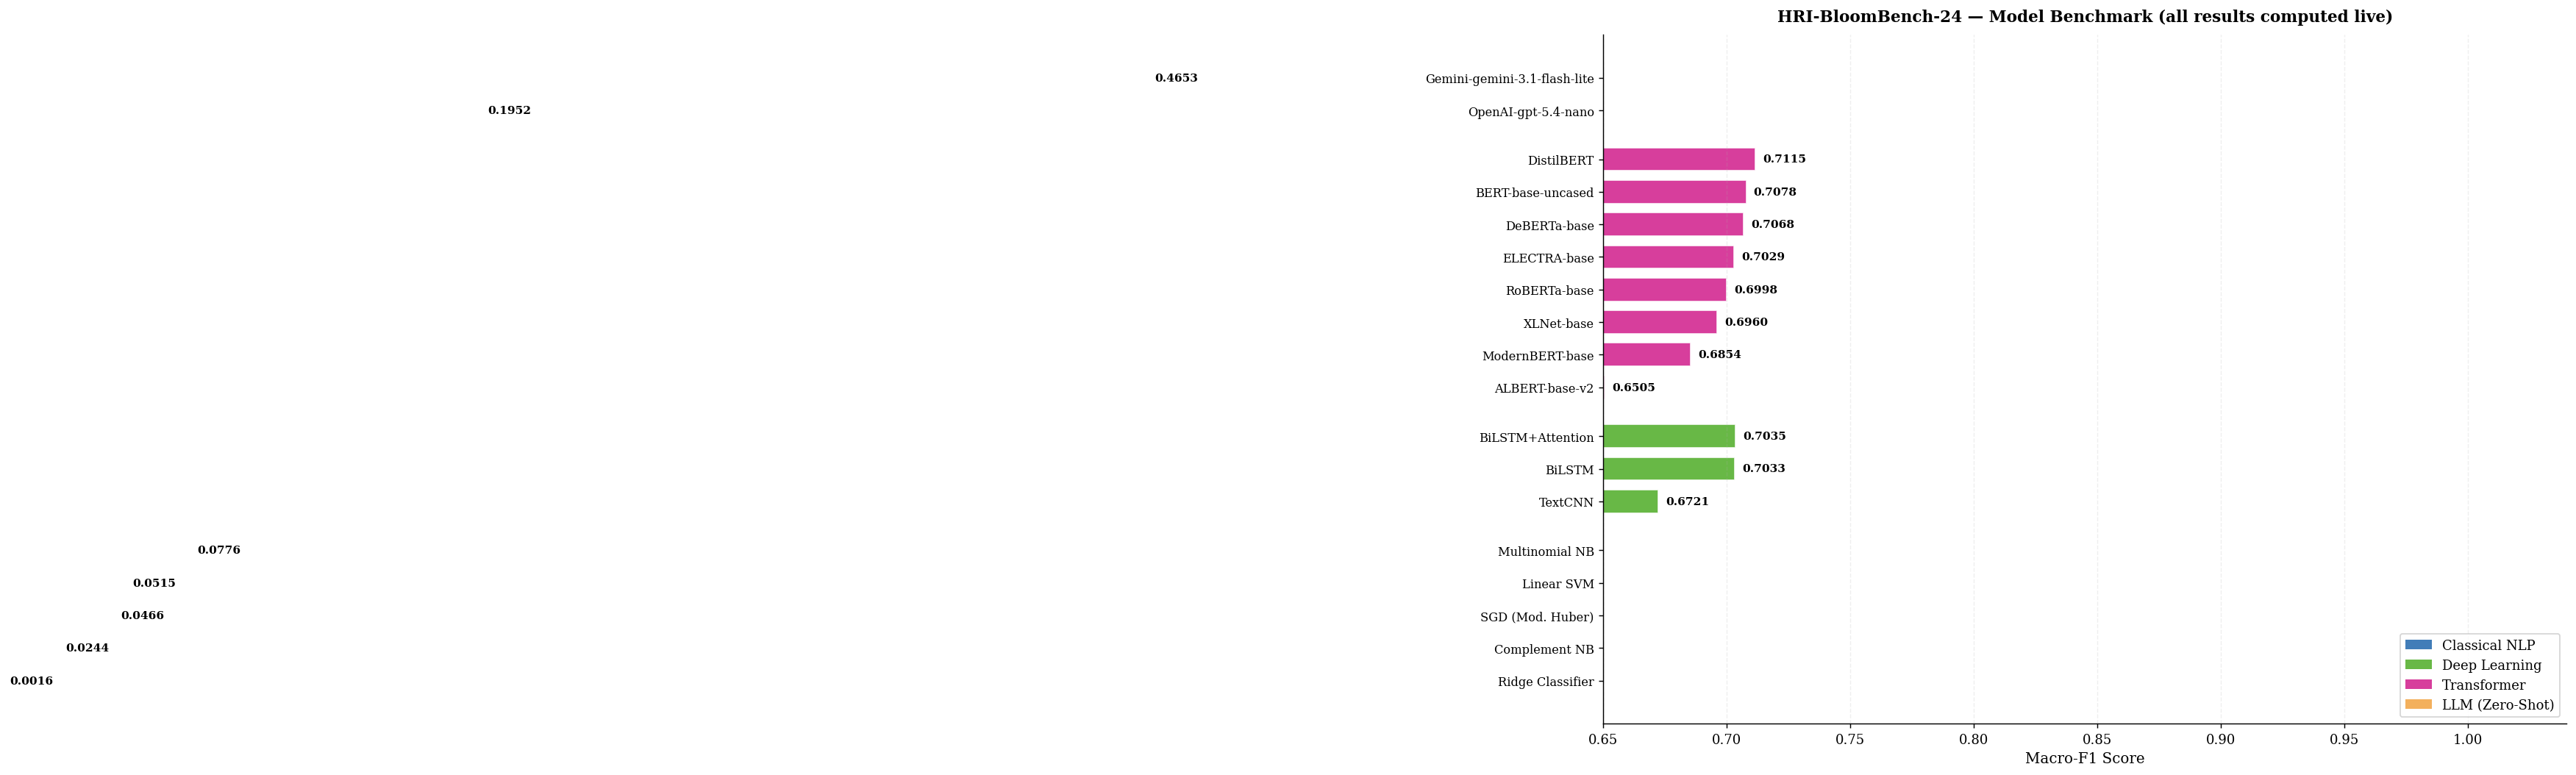

In [ ]:
# ── Ranking chart ─────────────────────────────────────────────────────────────
cats_present = [c for c in CAT_COLORS if c in all_results['Category'].values]
fig, ax = plt.subplots(figsize=(13, max(5, len(all_results) * 0.52)))
y_pos = 0; yticks = []; ylabels = []

for cat in cats_present:
    sub = all_results[all_results['Category'] == cat].sort_values('F1-Macro')
    for _, row in sub.iterrows():
        ax.barh(y_pos, row['F1-Macro'], color=CAT_COLORS[cat], alpha=0.85,
                edgecolor='white', height=0.72)
        ax.text(row['F1-Macro'] + 0.003, y_pos,
                f"{row['F1-Macro']:.4f}", va='center', fontsize=8.5, fontweight='bold')
        yticks.append(y_pos); ylabels.append(row['Model']); y_pos += 1
    y_pos += 0.5

ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel('Macro-F1 Score', fontsize=11); ax.set_xlim(0.65, 1.04)
ax.set_title('HRI-BloomBench-24 — Model Benchmark (all results computed live)',
             fontweight='bold', pad=10)
ax.grid(axis='x', alpha=0.2, ls='--')
ax.legend(handles=[Patch(facecolor=CAT_COLORS[c], label=c, alpha=0.85)
                   for c in cats_present], loc='lower right', fontsize=10)
plt.tight_layout(); plt.savefig('fig_benchmark.png', bbox_inches='tight', dpi=150)
plt.show()

## §12 — Confusion Matrix & Per-Class Analysis

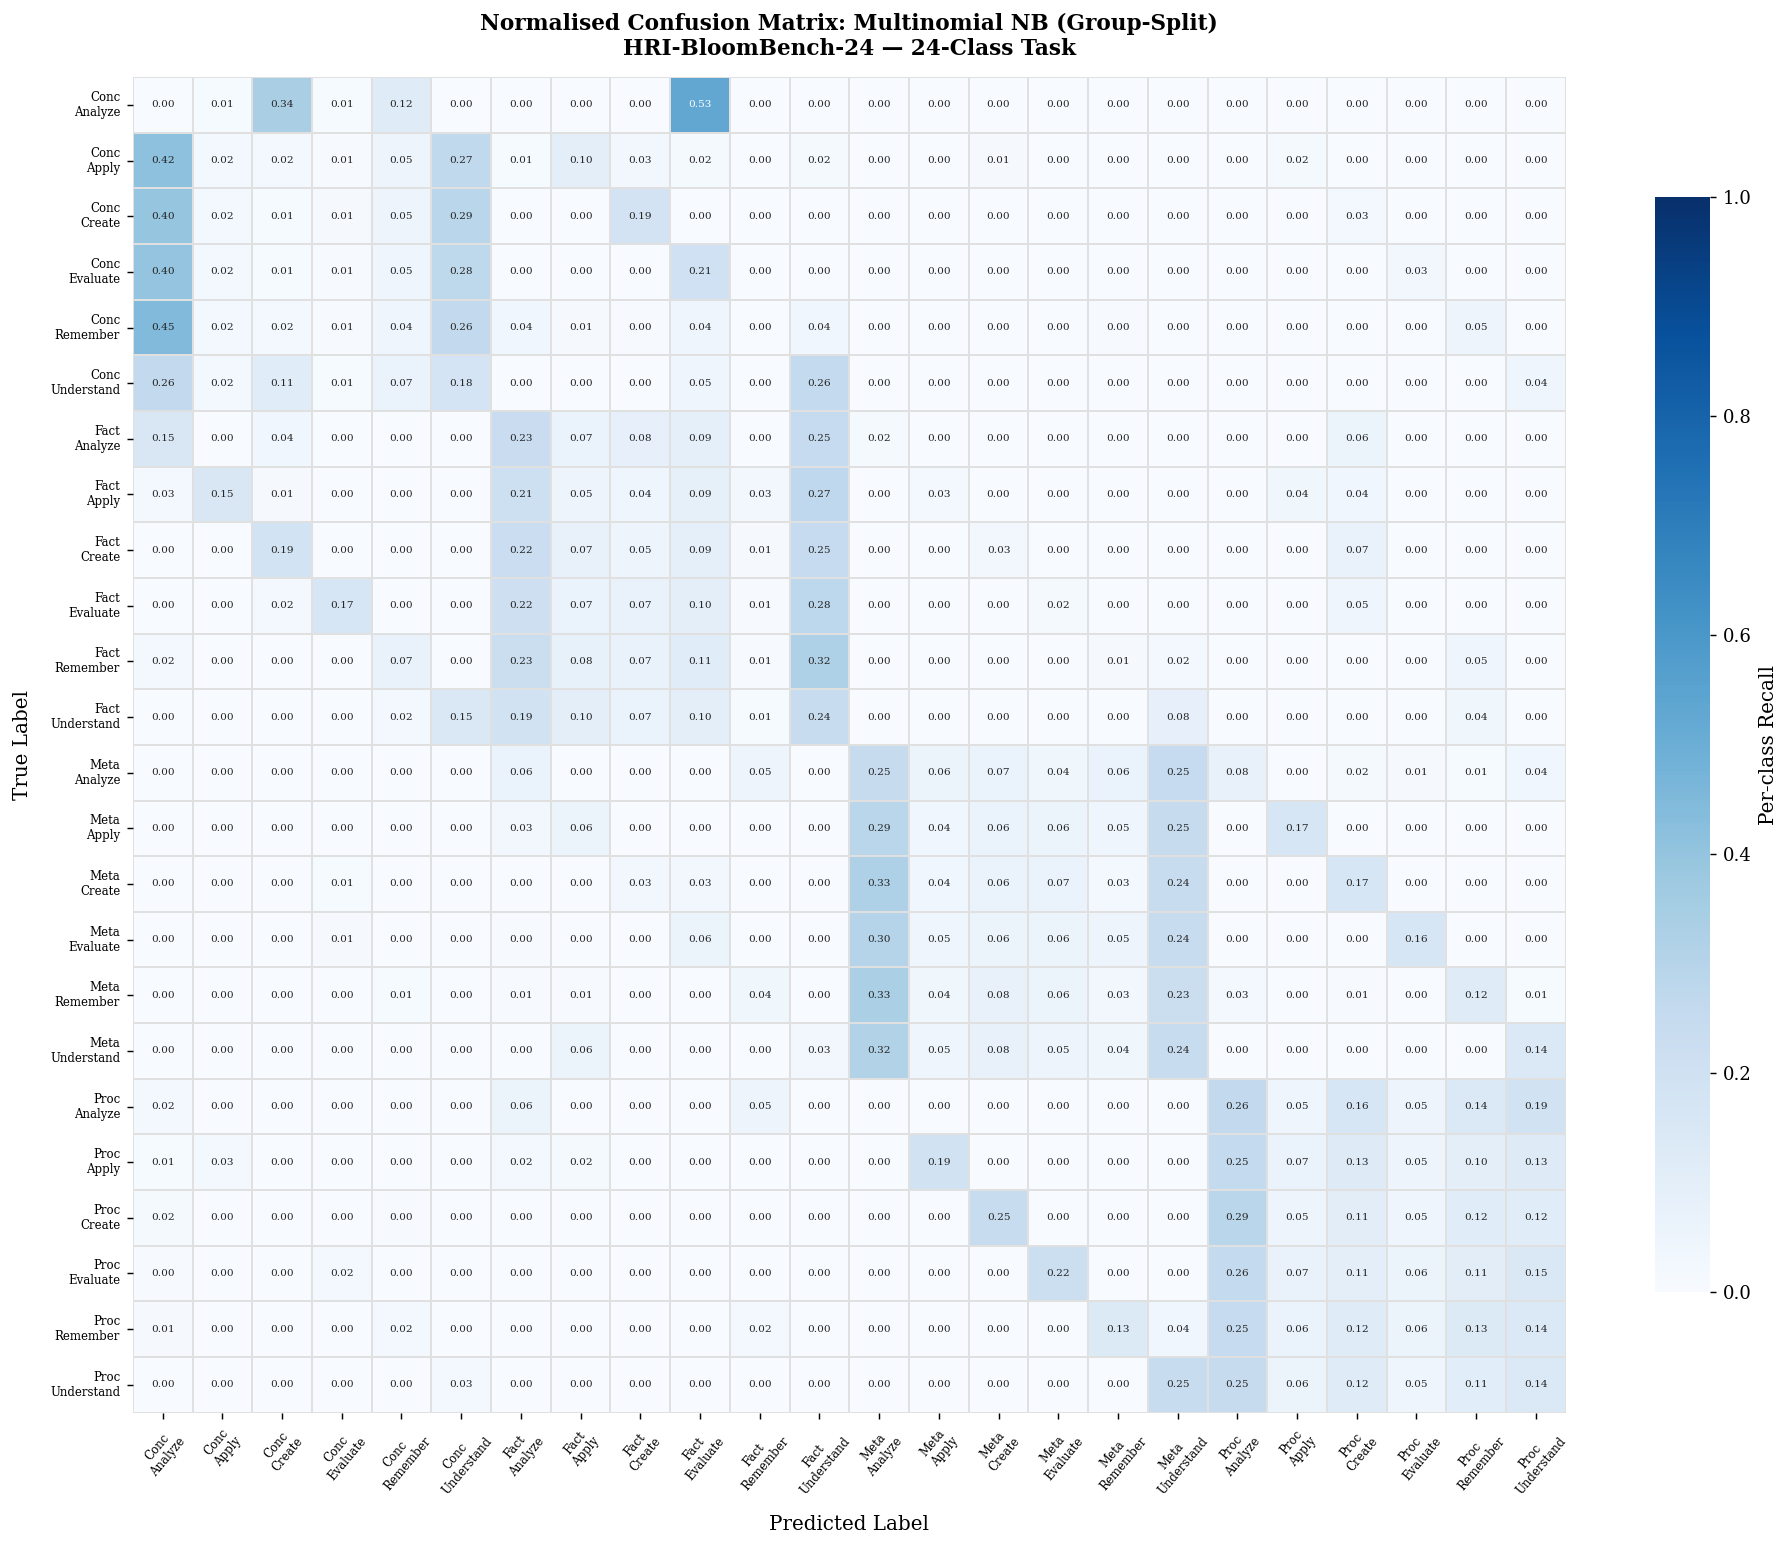

Mean per-class recall: 0.1003


In [ ]:
cm      = confusion_matrix(y_test, best_classical_pred, labels=labels_sorted)
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
short   = [l.replace('Metacognitive','Meta').replace('Procedural','Proc')
            .replace('Conceptual','Conc').replace('Factual','Fact').replace('_','\n')
            for l in labels_sorted]

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short, yticklabels=short, ax=ax,
            linewidths=0.25, linecolor='#e0e0e0',
            annot_kws={'size': 5.8}, vmin=0, vmax=1,
            cbar_kws={'label': 'Per-class Recall', 'shrink': 0.82})
ax.set_title(f'Normalised Confusion Matrix: {best_classical_name} (Group-Split)\n'
             'HRI-BloomBench-24 — 24-Class Task', fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', labelpad=10); ax.set_ylabel('True Label', labelpad=10)
ax.tick_params(axis='x', rotation=50, labelsize=6.5)
ax.tick_params(axis='y', rotation=0,  labelsize=6.5)
plt.tight_layout(); plt.savefig('fig_confusion.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Mean per-class recall: {np.diag(cm_norm).mean():.4f}")

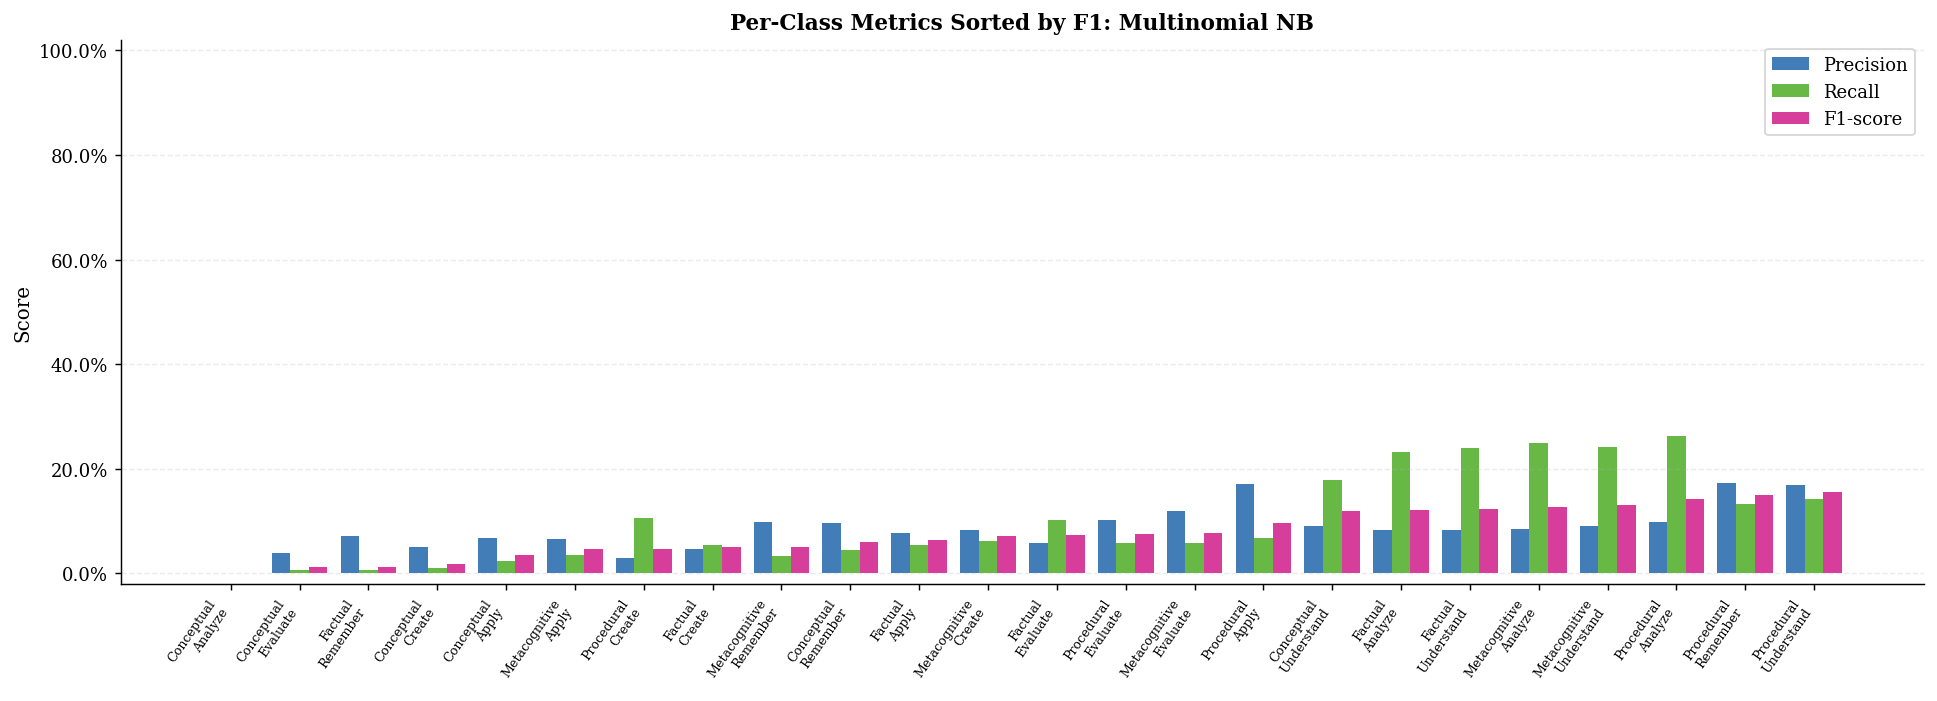


5 hardest classes:


,precision,recall,f1-score
Conceptual_Analyze,0.0000,0.0000,0.0000
Conceptual_Evaluate,0.0389,0.0068,0.0116
Factual_Remember,0.0723,0.0064,0.0118
Conceptual_Create,0.0507,0.0114,0.0186
Conceptual_Apply,0.0686,0.0245,0.0361



5 easiest classes:


,precision,recall,f1-score
Metacognitive_Analyze,0.0853,0.2488,0.1271
Metacognitive_Understand,0.0905,0.2420,0.1318
Procedural_Analyze,0.0984,0.2632,0.1432
Procedural_Remember,0.1725,0.1330,0.1502
Procedural_Understand,0.1689,0.1431,0.1549


In [26]:
rep     = classification_report(y_test, best_classical_pred, labels=labels_sorted,
                                output_dict=True, zero_division=0)
pcd     = pd.DataFrame(rep).T
pcd_cls = (pcd[pcd.index.isin(labels_sorted)]
              [['precision','recall','f1-score']].astype(float)
              .sort_values('f1-score'))

fig, ax = plt.subplots(figsize=(15, 5.5))
x2 = np.arange(len(pcd_cls)); w2 = 0.27
ax.bar(x2-w2, pcd_cls['precision'], w2, label='Precision', color='#2166ac', alpha=0.85)
ax.bar(x2,    pcd_cls['recall'],    w2, label='Recall',    color='#4dac26', alpha=0.85)
ax.bar(x2+w2, pcd_cls['f1-score'], w2, label='F1-score',  color='#d01c8b', alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels([l.replace('_','\n') for l in pcd_cls.index],
                   rotation=55, ha='right', fontsize=7)
ax.set_ylabel('Score'); ax.set_ylim(pcd_cls['f1-score'].min() - 0.02, 1.02)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.legend(); ax.grid(axis='y', alpha=0.25, ls='--')
ax.set_title(f'Per-Class Metrics Sorted by F1: {best_classical_name}', fontweight='bold')
plt.tight_layout(); plt.savefig('fig_perclass.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n5 hardest classes:"); display(pcd_cls.head(5).round(4))
print("\n5 easiest classes:"); display(pcd_cls.tail(5).round(4))


## §13 — Error Analysis

In [34]:
err = pd.DataFrame({'true': y_test, 'pred': best_classical_pred})
err = err[err['true'] != err['pred']].copy()
err['true_kd'] = err['true'].str.split('_').str[0]
err['pred_kd'] = err['pred'].str.split('_').str[0]
err['true_cp'] = err['true'].str.split('_').str[1]
err['pred_cp'] = err['pred'].str.split('_').str[1]

kd_wrong   = (err['true_kd'] != err['pred_kd']).sum()
cp_wrong   = (err['true_cp'] != err['pred_cp']).sum()
both_wrong = ((err['true_kd'] != err['pred_kd']) & (err['true_cp'] != err['pred_cp'])).sum()
total_err  = len(err)

# Mutually exclusive decomposition (these three sum exactly to total_err)
kd_only = kd_wrong - both_wrong   # only KD axis wrong
cp_only = cp_wrong - both_wrong   # only CP axis wrong
assert kd_only + cp_only + both_wrong == total_err, "Decomposition sanity check failed"

print(f"{'─'*55}")
print(f"Model           : {best_classical_name}")
print(f"Total errors    : {total_err:,}  ({total_err/len(y_test)*100:.2f}% error rate)")
print(f"KD-axis wrong   : {kd_wrong}  ({kd_wrong/max(total_err,1)*100:.1f}%)  [incl. both]")
print(f"CP-axis wrong   : {cp_wrong}  ({cp_wrong/max(total_err,1)*100:.1f}%)  [incl. both]")
print(f"Both axes wrong : {both_wrong}  ({both_wrong/max(total_err,1)*100:.1f}%)")
print(f"  → KD only     : {kd_only}  ({kd_only/max(total_err,1)*100:.1f}%)")
print(f"  → CP only     : {cp_only}  ({cp_only/max(total_err,1)*100:.1f}%)")
print(f"{'─'*55}")

err['pair'] = err['true'] + '  →  ' + err['pred']
top_pairs = err['pair'].value_counts().head(10).reset_index()
top_pairs.columns = ['Confusion Pair', 'Count']

print("\nTop confusion pairs:")
display(top_pairs)

───────────────────────────────────────────────────────
Model           : Multinomial NB
Total errors    : 33,764  (91.95% error rate)
KD-axis wrong   : 8915  (26.4%)  [incl. both]
CP-axis wrong   : 26671  (79.0%)  [incl. both]
Both axes wrong : 1822  (5.4%)
  → KD only     : 7093  (21.0%)
  → CP only     : 24849  (73.6%)
───────────────────────────────────────────────────────

Top confusion pairs:


,Confusion Pair,Count
0,Conceptual_Create → Conceptual_Analyze,1249
1,Factual_Remember → Factual_Understand,1203
2,Conceptual_Create → Conceptual_Understand,922
3,Conceptual_Remember → Conceptual_Analyze,895
4,Factual_Remember → Factual_Analyze,862
5,Conceptual_Evaluate → Conceptual_Analyze,759
6,Metacognitive_Remember → Metacognitive_Analyze,684
7,Conceptual_Apply → Conceptual_Analyze,611
8,Procedural_Apply → Procedural_Analyze,590
9,Conceptual_Create → Factual_Create,584


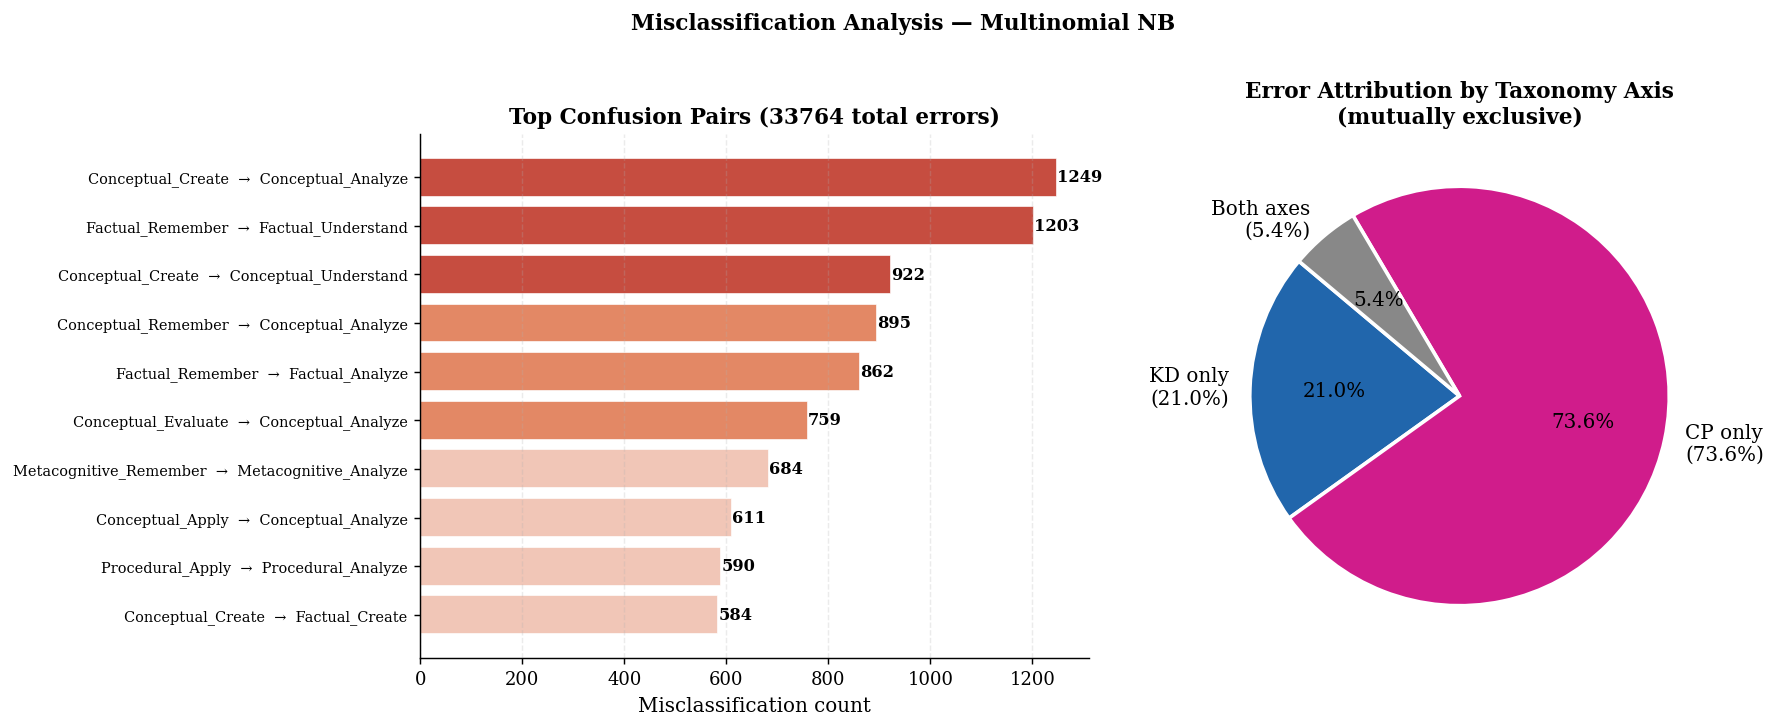

In [35]:
if total_err > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    ax = axes[0]
    cnts = top_pairs['Count'].values; labs = top_pairs['Confusion Pair'].values
    cols = ['#c0392b' if i<3 else '#e07b54' if i<6 else '#f0c0b0' for i in range(len(cnts))]
    ax.barh(range(len(cnts))[::-1], cnts, color=cols, alpha=0.9, edgecolor='white')
    ax.set_yticks(range(len(labs))[::-1]); ax.set_yticklabels(labs, fontsize=8)
    ax.set_xlabel('Misclassification count')
    ax.set_title(f'Top Confusion Pairs ({total_err} total errors)', fontweight='bold')
    ax.grid(axis='x', alpha=0.25, ls='--')
    for i, (cnt, yp_) in enumerate(zip(cnts, range(len(cnts))[::-1])):
        ax.text(cnt + 0.05, yp_, str(cnt), va='center', fontsize=9, fontweight='bold')

    ax2 = axes[1]
    # Use mutually exclusive slices: KD-only, CP-only, Both (sum = total_err)
    sizes_pie  = [kd_only, cp_only, both_wrong]
    labels_pie = [f'KD only\n({kd_only/max(total_err,1)*100:.1f}%)',
                  f'CP only\n({cp_only/max(total_err,1)*100:.1f}%)',
                  f'Both axes\n({both_wrong/max(total_err,1)*100:.1f}%)']
    colors_pie = ['#2166ac', '#d01c8b', '#888888']
    ax2.pie(sizes_pie, labels=labels_pie, colors=colors_pie,
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax2.set_title('Error Attribution by Taxonomy Axis\n(mutually exclusive)', fontweight='bold')
    plt.suptitle(f'Misclassification Analysis — {best_classical_name}', fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('fig_errors.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("✅ Perfect predictions — zero errors on test set!")


## §14 — Feature Importance (Log-Odds)

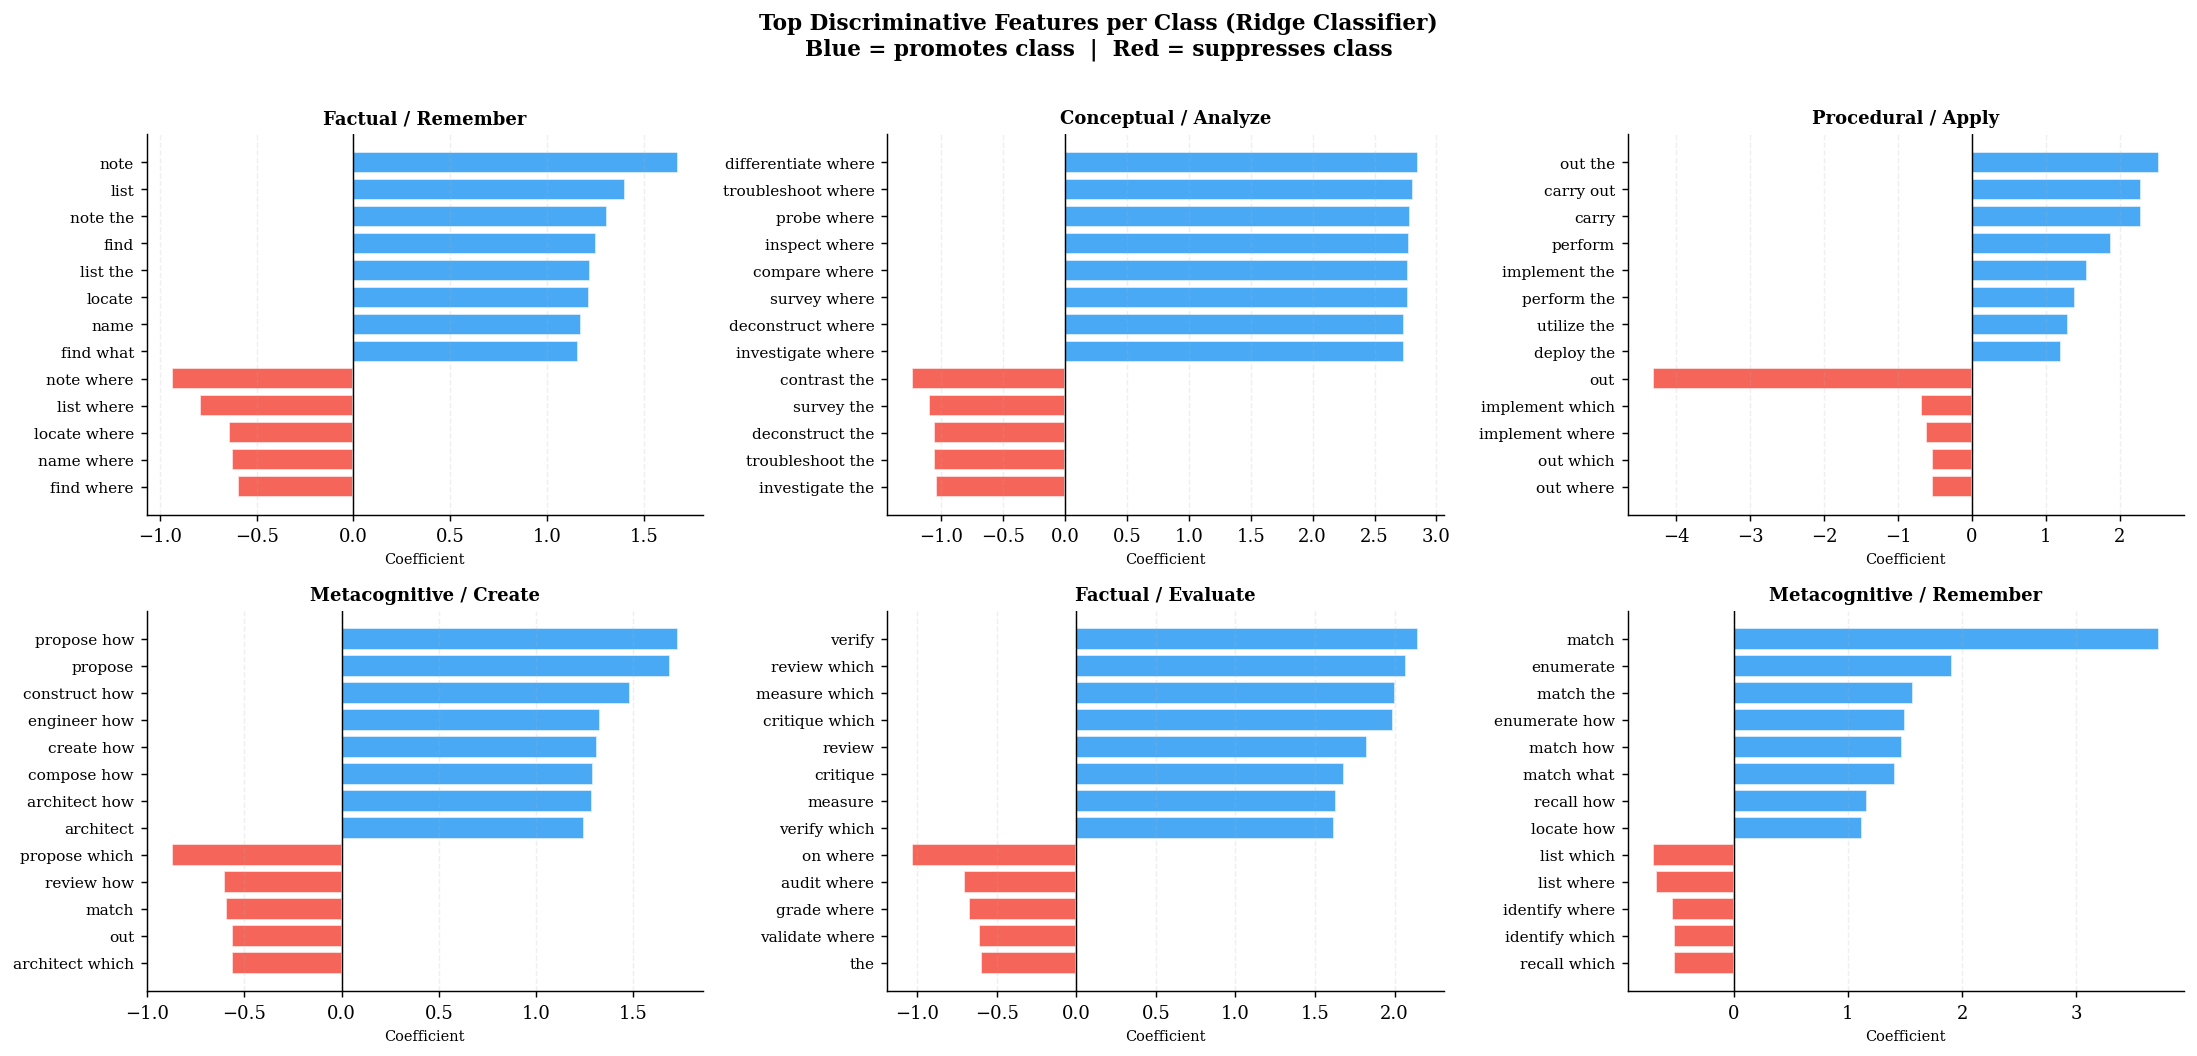

In [29]:
ridge_fi = RidgeClassifier(alpha=0.5)
ridge_fi.fit(Xtr_tf, y_train)
feat_names = np.array(tfidf.get_feature_names_out())
coef = ridge_fi.coef_

vis_classes = [c for c in
    ['Factual_Remember','Conceptual_Analyze','Procedural_Apply',
     'Metacognitive_Create','Factual_Evaluate','Metacognitive_Remember']
    if c in ridge_fi.classes_]

fig, axes = plt.subplots(2, 3, figsize=(17, 8)); axes = axes.ravel()
for i, cls in enumerate(vis_classes):
    idx = list(ridge_fi.classes_).index(cls); c = coef[idx]
    top_pos = np.argsort(c)[-10:][::-1]; top_neg = np.argsort(c)[:6]
    tf = np.concatenate([feat_names[top_pos[:8]], feat_names[top_neg[:5]]])
    tv = np.concatenate([c[top_pos[:8]],          c[top_neg[:5]]])
    cb = ['#2196F3' if v > 0 else '#F44336' for v in tv]
    axes[i].barh(range(len(tf)), tv, color=cb, alpha=0.82, edgecolor='white')
    axes[i].set_yticks(range(len(tf))); axes[i].set_yticklabels(tf, fontsize=8.5)
    axes[i].set_title(cls.replace('_', ' / '), fontsize=10, fontweight='bold')
    axes[i].axvline(0, color='black', lw=0.8); axes[i].invert_yaxis()
    axes[i].set_xlabel('Coefficient', fontsize=8); axes[i].grid(axis='x', alpha=0.2, ls='--')

plt.suptitle('Top Discriminative Features per Class (Ridge Classifier)\n'
             'Blue = promotes class  |  Red = suppresses class', fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('fig_features.png', bbox_inches='tight', dpi=150)
plt.show()


## §15 — Natural HRI Interaction Demo

In [ ]:
BLOOM_LEVELS = {'Remember':0,'Understand':1,'Apply':2,'Analyze':3,'Evaluate':4,'Create':5}
KD_DESC = {
    'Factual'      :'Specific facts, affordance records, object locations',
    'Conceptual'   :'Categories, principles, affordance taxonomies',
    'Procedural'   :'Step-by-step methods, grasping sequences',
    'Metacognitive':'Self-monitoring, cognitive strategy, meta-awareness',
}
CP_DESC = {
    'Remember'  :'Recall, locate, name, define            [LOTS — Level 1/6]',
    'Understand':'Describe, explain, summarise            [LOTS — Level 2/6]',
    'Apply'     :'Use, execute, perform                   [LOTS — Level 3/6]',
    'Analyze'   :'Compare, contrast, examine              [HOTS — Level 4/6]',
    'Evaluate'  :'Judge, rate, critique                   [HOTS — Level 5/6]',
    'Create'    :'Generate, design, propose               [HOTS — Level 6/6]',
}

def classify_hri(sentence, use_llm=False):
    # ── DistilBERT inference (primary) ───────────────────────────────────────
    _db_available = 'tokenizer_db' in dir() and 'model_db' in dir()
    if _db_available:
        import torch
        inputs = tokenizer_db(sentence, return_tensors='pt',
                              truncation=True, max_length=128)
        with torch.no_grad():
            logits = model_db(**inputs).logits
        pred_id = logits.argmax(-1).item()
        pred    = id2label_sa[pred_id]
        model_label = 'DistilBERT'
    else:
        # Fallback to best classical if §17 has not been run
        feat  = tfidf.transform([sentence])
        pred  = trained_models[best_classical_name].predict(feat)[0]
        model_label = best_classical_name + ' (fallback)'

    kd, cp = pred.split('_', 1)
    level = BLOOM_LEVELS[cp]
    cat   = 'LOTS (Lower-Order)' if level < 3 else 'HOTS (Higher-Order)'
    bar   = '\u2593' * (level + 1) + '\u2591' * (5 - level)

    print(f"\n{'=' * 68}")
    print(f"  Input  : {sentence}")
    print(f"{'=' * 68}")
    print(f"\n  \U0001f916 {model_label}:")
    print(f"     Predicted Class     : {pred}")
    print(f"     Knowledge Dimension : {kd} \u2014 {KD_DESC[kd]}")
    print(f"     Cognitive Process   : {cp} \u2014 {CP_DESC[cp]}")
    print(f"     Bloom Level         : {bar} ({level+1}/6) \u2014 {cat}")

    if use_llm:
        for fn, name, active in [
            (classify_gemini, 'Gemini-Flash-Lite', USE_GEMINI),
            (classify_openai, 'OpenAI GPT-nano',   USE_OPENAI),
        ]:
            if active:
                print(f"\n  \U0001f4ac {name} (Zero-Shot):")
                res = fn(sentence)
                g_lbl = res.get('label', 'unknown')
                match = '\u2705 Agrees' if g_lbl == pred else '\U0001f504 Differs'
                print(f"     Predicted : {g_lbl}  {match}")
                if res.get('reasoning'):
                    print(f"     Reasoning : {res['reasoning'][:200]}")

demo_sentences = [
    "Can you bring me the cup from the right side of the table?",
    "Describe the step-by-step procedure for safely grasping the fragile glass.",
    "Explain why the orange belongs to the edible category.",
    "Design a self-monitoring framework for the robot's cognitive cycle.",
    "Compare the book and the phone to determine which best serves the human's request.",
    "Rate whether the grasping procedure for the pen was applied correctly.",
]
for sent in demo_sentences:
    classify_hri(sent, use_llm=False)
print()


In [ ]:
# ── Try your own command ──────────────────────────────────────────────────────
MY_COMMAND = "Please retrieve the notebook from the left side of the table."
classify_hri(MY_COMMAND, use_llm=(USE_GEMINI or USE_OPENAI))



════════════════════════════════════════════════════════════════════
  Input  : Please retrieve the notebook from the left side of the table.
════════════════════════════════════════════════════════════════════

  🤖 Multinomial NB + TF-IDF Bigram:
     Predicted Class     : Factual_Analyze
     Knowledge Dimension : Factual — Specific facts, affordance records, object locations
     Cognitive Process   : Analyze — Compare, contrast, examine              [HOTS — Level 4/6]
     Bloom Level         : ▓▓▓▓░░ (4/6) — HOTS (Higher-Order)

  📊 Top-5 Confidence (Logistic Regression):
     Procedural_Remember                 0.1035  ████
     Procedural_Analyze                  0.1004  ████
     Factual_Apply                       0.0878  ███
     Procedural_Understand               0.0874  ███
     Factual_Analyze                     0.0857  ███

  💬 Gemini-2.0-Flash (Zero-Shot):
     Predicted : Factual_Remember  🔄 Differs
     Reasoning : The instruction requires the robot to recall or loc

In [ ]:
# ── Save all outputs ──────────────────────────────────────────────────────────
classical_df.to_csv('classical_results.csv', index=False)
abl_df.to_csv('ablation_results.csv', index=False)
sub_df.to_csv('subtask_results.csv', index=False)
if 'all_results' in dir() and len(all_results) > 0:
    all_results.to_csv('benchmark_all_results.csv', index=False)

print("=== Saved Files ===")
for f in ['classical_results.csv','ablation_results.csv','subtask_results.csv',
          'benchmark_all_results.csv','dl_results.csv','transformer_results.csv',
          'llm_results.csv','fig_benchmark.png','fig_confusion.png',
          'fig_perclass.png','fig_errors.png','fig_features.png']:
    status = '✅' if os.path.exists(f) else '⬜ (not yet generated)'
    print(f"  {status}  {f}")

print("\n=== CITATION ===")
print("Bukhari S.T.S., Malik M.I., Yaseen F., Ware A. (2025).")
print("HRI-BloomBench-24: A Balanced NLP Benchmark for Bloom's Revised")
print("Taxonomy Classification in Human-Robot Interaction Scenarios.")
print("Cognitive Robotics Group, University of Central Punjab, Lahore.")


## §16 — Full Model Comparison (Loaded from Saved Results)

Results loaded from the three CSV files saved before the kernel crash:
- `dl_results.csv` — Deep Learning (TextCNN, BiLSTM, BiLSTM+Attention)
- `transformer_results.csv` — Transformer fine-tuned models (8 models)
- `llm_results.csv` — LLM zero-shot evaluation (Gemini, OpenAI)

In [14]:
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
from IPython.display import display

# ── Load saved CSVs ───────────────────────────────────────────────────────────
_base = os.path.dirname(os.path.abspath('HRI_BloomBench24_Benchmark_5.ipynb'))

def _load(name):
    path = os.path.join(_base, name)
    if not os.path.exists(path):
        print(f"⚠️  Not found: {path}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f"✅ Loaded {name}  ({len(df)} rows)")
    return df

dl_df   = _load('dl_results.csv')
tr_df   = _load('transformer_results.csv')
llm_df_ = _load('llm_results.csv')

# ── Normalise LLM frame (drop extra columns) ──────────────────────────────────
keep = ['Model', 'Acc', 'F1-Macro', 'F1-Weighted', 'Kappa', 'MCC', 'Params', 'Time_s', 'Category']
if not llm_df_.empty:
    llm_df_ = llm_df_[[c for c in keep if c in llm_df_.columns]]

frames = [f for f in [dl_df, tr_df, llm_df_] if not f.empty]
all_res = pd.concat(frames, ignore_index=True)
all_res.sort_values('F1-Macro', ascending=False, inplace=True)
all_res.reset_index(drop=True, inplace=True)
all_res.index += 1

print(f"\n{'─'*55}")
print(f"  Total models loaded: {len(all_res)}")
print(f"  Categories: {', '.join(all_res['Category'].unique())}")
print(f"{'─'*55}")

# ── Styled summary table ──────────────────────────────────────────────────────
CAT_COLORS = {
    'Deep Learning'  : '#4dac26',
    'Transformer'    : '#d01c8b',
    'LLM (Zero-Shot)': '#f1a340',
}

def _row_color(row):
    c = CAT_COLORS.get(row['Category'], '#cccccc')
    return [f'background-color: {c}22'] * len(row)

styled = (all_res[['Model', 'Category', 'Acc', 'F1-Macro', 'F1-Weighted', 'Kappa', 'MCC', 'Params', 'Time_s']]
    .style
    .apply(_row_color, axis=1)
    .format({'Acc': '{:.4f}', 'F1-Macro': '{:.4f}', 'F1-Weighted': '{:.4f}',
             'Kappa': '{:.4f}', 'MCC': '{:.4f}'})
    .background_gradient(cmap='YlGn', subset=['F1-Macro', 'Acc', 'MCC'])
    .set_caption(f"HRI-BloomBench-24 — {len(all_res)}-Model Benchmark (saved results)"))

display(styled)

all_res.to_csv(os.path.join(_base, 'benchmark_all_results.csv'), index=False)
print(f"\nSaved → benchmark_all_results.csv")

✅ Loaded dl_results.csv  (3 rows)
✅ Loaded transformer_results.csv  (8 rows)
✅ Loaded llm_results.csv  (2 rows)

───────────────────────────────────────────────────────
  Total models loaded: 13
  Categories: Transformer, Deep Learning, LLM (Zero-Shot)
───────────────────────────────────────────────────────


,Model,Category,Acc,F1-Macro,F1-Weighted,Kappa,MCC,Params,Time_s
1,DistilBERT,Transformer,0.7397,0.7115,0.7459,0.7261,0.7267,67M,581.000000
2,BERT-base-uncased,Transformer,0.7374,0.7078,0.7445,0.7237,0.7244,110M,1010.000000
3,DeBERTa-base,Transformer,0.7347,0.7068,0.7413,0.7208,0.7214,139M,2213.000000
4,BiLSTM+Attention,Deep Learning,0.7308,0.7035,0.7350,0.7166,0.7176,2.4M,308.900000
5,BiLSTM,Deep Learning,0.7392,0.7033,0.7423,0.7255,0.7263,2.4M,291.300000
6,ELECTRA-base,Transformer,0.7254,0.7029,0.7314,0.7114,0.7125,110M,990.000000
7,RoBERTa-base,Transformer,0.7169,0.6998,0.7249,0.7026,0.7041,125M,1052.000000
8,XLNet-base,Transformer,0.7225,0.6960,0.7292,0.7082,0.7093,117M,2112.000000
9,ModernBERT-base,Transformer,0.7093,0.6854,0.7173,0.6943,0.6954,150M,1665.000000
10,TextCNN,Deep Learning,0.7258,0.6721,0.7249,0.7113,0.7122,0.2M,53.900000



Saved → benchmark_all_results.csv


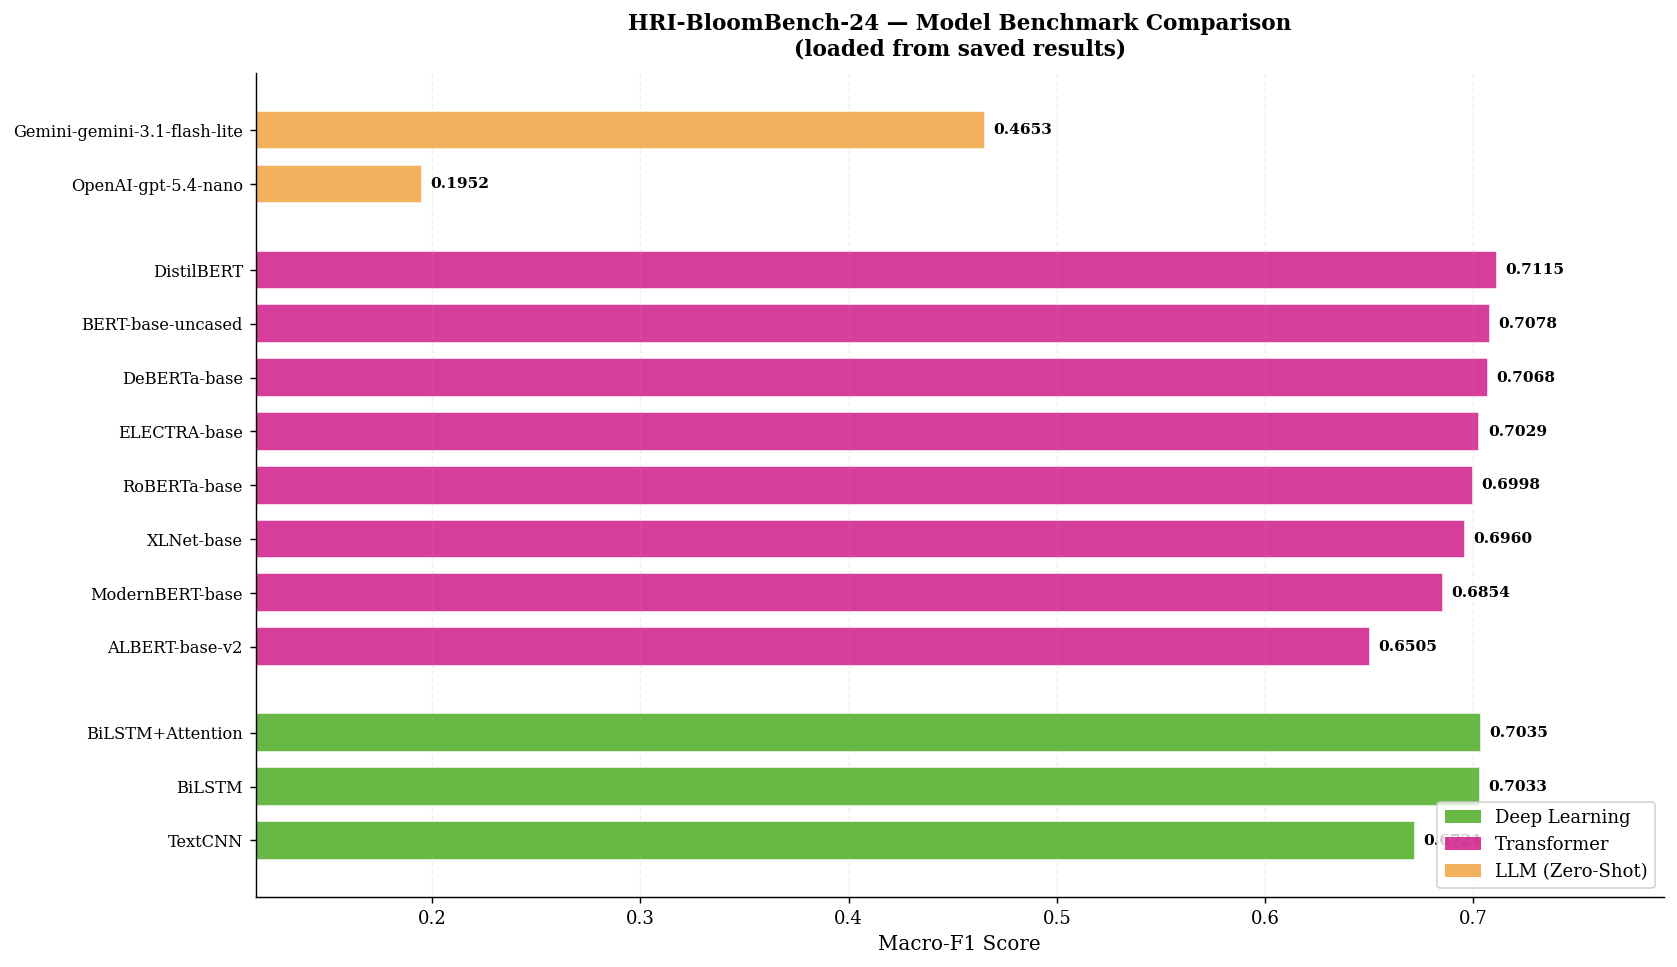

Saved → fig_benchmark_saved.png


In [15]:
# ── Horizontal bar chart ranked by F1-Macro ───────────────────────────────────
cats_present = [c for c in CAT_COLORS if c in all_res['Category'].values]

fig, ax = plt.subplots(figsize=(13, max(5, len(all_res) * 0.58)))
y_pos = 0; yticks = []; ylabels = []

for cat in cats_present:
    sub = all_res[all_res['Category'] == cat].sort_values('F1-Macro')
    for _, row in sub.iterrows():
        ax.barh(y_pos, row['F1-Macro'], color=CAT_COLORS[cat], alpha=0.85,
                edgecolor='white', height=0.72)
        ax.text(row['F1-Macro'] + 0.004, y_pos,
                f"{row['F1-Macro']:.4f}", va='center', fontsize=8.5, fontweight='bold')
        yticks.append(y_pos); ylabels.append(row['Model']); y_pos += 1
    y_pos += 0.6   # gap between categories

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel('Macro-F1 Score', fontsize=11)

x_min = max(0, all_res['F1-Macro'].min() - 0.08)
ax.set_xlim(x_min, min(1.0, all_res['F1-Macro'].max() + 0.08))
ax.set_title('HRI-BloomBench-24 — Model Benchmark Comparison\n(loaded from saved results)',
             fontweight='bold', pad=10)
ax.grid(axis='x', alpha=0.2, ls='--')
ax.legend(handles=[Patch(facecolor=CAT_COLORS[c], label=c, alpha=0.85)
                   for c in cats_present],
          loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(_base, 'fig_benchmark_saved.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved → fig_benchmark_saved.png")

## §17 — DistilBERT Inference, Sub-task Decomposition & Error Analysis

**Standalone section** — reconstructs the group-split and loads DistilBERT from the
saved checkpoint. Does **not** require re-running §1–§16.

Produces:
- `distilbert_pred` — model predictions on the group-split test set
- Sub-task decomposition table (KD-4cls / CP-6cls / joint 24-class)
- Figs 04–07 saved to `figs/`

In [ ]:
# §17-A — Data loading & group-split reconstruction (standalone)
import warnings, os, json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    matthews_corrcoef, confusion_matrix, classification_report
)
from sklearn.linear_model import RidgeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

SEED_SA = 42
DATA_PATH_SA = '../dataset/HRI_BloomBench24_v2.csv'   # update if renamed
FIGS_DIR    = 'figs'
os.makedirs(FIGS_DIR, exist_ok=True)

# Load & normalise
df_sa = pd.read_csv(DATA_PATH_SA)
df_sa.columns = [c.strip().lower().replace(' ', '_') for c in df_sa.columns]

# Deduplicate + group construction (mirrors Cell 14 exactly)
df_u_sa = df_sa.drop_duplicates(subset=['sentence']).reset_index(drop=True).copy()
df_u_sa['verb']  = df_u_sa['sentence'].str.split().str[0].str.lower()
df_u_sa['group'] = df_u_sa['verb'] + '__' + df_u_sa['kd']
groups_sa = df_u_sa['group'].unique()

for attempt in range(40):
    np.random.seed(SEED_SA + attempt)
    test_grps_sa = set(np.random.choice(groups_sa,
                        size=max(int(len(groups_sa) * 0.20), 1), replace=False))
    if df_u_sa[df_u_sa['group'].isin(test_grps_sa)]['label'].nunique() == 24:
        print(f'Valid split: attempt={attempt+1}')
        break

tr_mask_sa = ~df_u_sa['group'].isin(test_grps_sa)
te_mask_sa =  df_u_sa['group'].isin(test_grps_sa)

X_train_sa = df_u_sa[tr_mask_sa]['sentence'].values
X_test_sa  = df_u_sa[te_mask_sa]['sentence'].values
y_train_sa = df_u_sa[tr_mask_sa]['label'].values
y_test_sa  = df_u_sa[te_mask_sa]['label'].values
y_kd_train_sa = df_u_sa[tr_mask_sa]['kd'].values
y_kd_test_sa  = df_u_sa[te_mask_sa]['kd'].values
y_cp_train_sa = df_u_sa[tr_mask_sa]['cp'].values
y_cp_test_sa  = df_u_sa[te_mask_sa]['cp'].values
labels_sorted_sa = sorted(df_u_sa['label'].unique())
label2id_sa = {l: i for i, l in enumerate(labels_sorted_sa)}
id2label_sa = {i: l for i, l in enumerate(labels_sorted_sa)}

overlap = len(set(X_train_sa) & set(X_test_sa))
print(f'Train: {len(X_train_sa):,}  Test: {len(X_test_sa):,}  Overlap: {overlap} (must be 0)')
print(f'Test label coverage: {len(set(y_test_sa))}/24')

In [ ]:
# §17-B — DistilBERT inference from saved checkpoint
try:
    import torch
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                               Trainer, DataCollatorWithPadding)
    from datasets import Dataset as HFDataset
    TORCH_SA = True
    DEVICE_SA = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'PyTorch {torch.__version__} | Device: {DEVICE_SA}')
except ImportError:
    TORCH_SA = False
    print('PyTorch / Transformers not available')

if TORCH_SA:
    DISTILBERT_DIR = './checkpoints/DistilBERT'
    print(f'Loading DistilBERT from {DISTILBERT_DIR} ...')
    tokenizer_db = AutoTokenizer.from_pretrained(DISTILBERT_DIR)
    model_db = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_DIR)

    def _tok_db(examples):
        return tokenizer_db(examples['text'], truncation=True, max_length=128)

    test_hf_db = (HFDataset
        .from_dict({'text':  list(X_test_sa),
                    'label': [label2id_sa[y] for y in y_test_sa]})
        .map(_tok_db, batched=True, desc='Tokenising'))

    eval_trainer_db = Trainer(
        model=model_db,
        data_collator=DataCollatorWithPadding(tokenizer_db)
    )
    preds_out_db   = eval_trainer_db.predict(test_hf_db)
    distilbert_pred = np.array([id2label_sa[i]
                                  for i in preds_out_db.predictions.argmax(-1)])

    acc_db = accuracy_score(y_test_sa, distilbert_pred)
    f1_db  = f1_score(y_test_sa, distilbert_pred, average='macro', zero_division=0)
    print(f'\nDistilBERT  Acc={acc_db:.4f}  F1-Macro={f1_db:.4f}')
    print(f'Predictions generated: {len(distilbert_pred):,}')

In [ ]:
# §17-C — Sub-task decomposition: DistilBERT (joint → KD + CP axis accuracy)
if TORCH_SA:
    from IPython.display import display

    kd_pred_db = np.array([p.split('_')[0] for p in distilbert_pred])
    cp_pred_db = np.array([p.split('_')[1] for p in distilbert_pred])

    subtask_db = pd.DataFrame([
        {'Model': 'DistilBERT', 'Task': '24-Class Joint',
         'Acc': accuracy_score(y_test_sa, distilbert_pred),
         'F1-Macro': f1_score(y_test_sa, distilbert_pred, average='macro', zero_division=0)},
        {'Model': 'DistilBERT', 'Task': 'KD-4cls',
         'Acc': accuracy_score(y_kd_test_sa, kd_pred_db),
         'F1-Macro': f1_score(y_kd_test_sa, kd_pred_db, average='macro', zero_division=0)},
        {'Model': 'DistilBERT', 'Task': 'CP-6cls',
         'Acc': accuracy_score(y_cp_test_sa, cp_pred_db),
         'F1-Macro': f1_score(y_cp_test_sa, cp_pred_db, average='macro', zero_division=0)},
        # Ridge reference row (from Cell 20)
        {'Model': 'Ridge', 'Task': '24-Class Joint', 'Acc': 0.0018, 'F1-Macro': 0.0016},
        {'Model': 'Ridge', 'Task': 'KD-4cls',        'Acc': 0.7727, 'F1-Macro': 0.7740},
        {'Model': 'Ridge', 'Task': 'CP-6cls',        'Acc': 0.9456, 'F1-Macro': 0.9318},
    ])

    display(subtask_db.style
            .format({'Acc': '{:.4f}', 'F1-Macro': '{:.4f}'})
            .background_gradient(cmap='YlGn', subset=['Acc', 'F1-Macro'])
            .set_caption('Sub-task Decomposition: DistilBERT vs Ridge — '
                         'Axis-Interaction Gap'))

    subtask_db.to_csv('subtask_distilbert.csv', index=False)
    print('Saved subtask_distilbert.csv')

In [ ]:
# §17-D — Confusion matrix (DistilBERT)
if TORCH_SA:
    cm_db      = confusion_matrix(y_test_sa, distilbert_pred, labels=labels_sorted_sa)
    cm_norm_db = cm_db.astype(float) / np.maximum(cm_db.sum(axis=1, keepdims=True), 1)
    short_db   = [l.replace('Metacognitive','Meta').replace('Procedural','Proc')
                   .replace('Conceptual','Conc').replace('Factual','Fact').replace('_','\n')
                   for l in labels_sorted_sa]

    fig, ax = plt.subplots(figsize=(15, 12))
    sns.heatmap(cm_norm_db, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=short_db, yticklabels=short_db, ax=ax,
                linewidths=0.25, linecolor='#e0e0e0',
                annot_kws={'size': 5.8}, vmin=0, vmax=1,
                cbar_kws={'label': 'Per-class Recall', 'shrink': 0.82})
    ax.set_title('Normalised Confusion Matrix: DistilBERT (Group-Split)\n'
                 'HRI-BloomBench-24 — 24-Class Task', fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', labelpad=10)
    ax.set_ylabel('True Label', labelpad=10)
    ax.tick_params(axis='x', rotation=50, labelsize=6.5)
    ax.tick_params(axis='y', rotation=0,  labelsize=6.5)
    plt.tight_layout()
    plt.savefig(f'{FIGS_DIR}/fig04_confusion_matrix_distilbert.png', bbox_inches='tight', dpi=150)
    plt.savefig('fig_confusion.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Mean per-class recall: {np.diag(cm_norm_db).mean():.4f}')

In [ ]:
# §17-E — Per-class precision / recall / F1 (DistilBERT)
if TORCH_SA:
    rep_db  = classification_report(y_test_sa, distilbert_pred,
                                     labels=labels_sorted_sa,
                                     output_dict=True, zero_division=0)
    pcd_db  = pd.DataFrame(rep_db).T
    pcd_cls_db = (pcd_db[pcd_db.index.isin(labels_sorted_sa)]
                   [['precision','recall','f1-score']].astype(float)
                   .sort_values('f1-score'))

    fig, ax = plt.subplots(figsize=(15, 5.5))
    x2 = np.arange(len(pcd_cls_db)); w2 = 0.27
    ax.bar(x2-w2, pcd_cls_db['precision'], w2, label='Precision', color='#2166ac', alpha=0.85)
    ax.bar(x2,    pcd_cls_db['recall'],    w2, label='Recall',    color='#4dac26', alpha=0.85)
    ax.bar(x2+w2, pcd_cls_db['f1-score'], w2, label='F1-score',  color='#d01c8b', alpha=0.85)
    ax.set_xticks(x2)
    ax.set_xticklabels([l.replace('_','\n') for l in pcd_cls_db.index],
                       rotation=55, ha='right', fontsize=7)
    ax.set_ylabel('Score')
    ax.set_ylim(max(0, pcd_cls_db['f1-score'].min() - 0.05), 1.02)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
    ax.legend(); ax.grid(axis='y', alpha=0.25, ls='--')
    ax.set_title('Per-Class Metrics Sorted by F1: DistilBERT', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{FIGS_DIR}/fig05_per_class_distilbert.png', bbox_inches='tight', dpi=150)
    plt.savefig('fig_perclass.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('\n5 hardest classes:')
    display(pcd_cls_db.head(5).round(4))
    print('\n5 easiest classes:')
    display(pcd_cls_db.tail(5).round(4))

In [ ]:
# §17-F — Misclassification error analysis (DistilBERT)
if TORCH_SA:
    err_db = pd.DataFrame({'true': y_test_sa, 'pred': distilbert_pred})
    err_db = err_db[err_db['true'] != err_db['pred']].copy()
    err_db['true_kd'] = err_db['true'].str.split('_').str[0]
    err_db['pred_kd'] = err_db['pred'].str.split('_').str[0]
    err_db['true_cp'] = err_db['true'].str.split('_').str[1]
    err_db['pred_cp'] = err_db['pred'].str.split('_').str[1]

    kd_wrong_db   = (err_db['true_kd'] != err_db['pred_kd']).sum()
    cp_wrong_db   = (err_db['true_cp'] != err_db['pred_cp']).sum()
    both_wrong_db = ((err_db['true_kd'] != err_db['pred_kd']) &
                     (err_db['true_cp'] != err_db['pred_cp'])).sum()
    total_err_db  = len(err_db)
    kd_only_db    = kd_wrong_db  - both_wrong_db
    cp_only_db    = cp_wrong_db  - both_wrong_db

    print(f'{"─"*55}')
    print(f'Model          : DistilBERT')
    print(f'Total errors   : {total_err_db:,}  ({total_err_db/len(y_test_sa)*100:.2f}% error rate)')
    print(f'KD-axis wrong  : {kd_wrong_db}  ({kd_wrong_db/max(total_err_db,1)*100:.1f}%)  [incl. both]')
    print(f'CP-axis wrong  : {cp_wrong_db}  ({cp_wrong_db/max(total_err_db,1)*100:.1f}%)  [incl. both]')
    print(f'Both axes wrong: {both_wrong_db}  ({both_wrong_db/max(total_err_db,1)*100:.1f}%)')
    print(f'  KD only      : {kd_only_db}  ({kd_only_db/max(total_err_db,1)*100:.1f}%)')
    print(f'  CP only      : {cp_only_db}  ({cp_only_db/max(total_err_db,1)*100:.1f}%)')
    print(f'{"─"*55}')

    err_db['pair'] = err_db['true'] + '  →  ' + err_db['pred']
    top_pairs_db = err_db['pair'].value_counts().head(10).reset_index()
    top_pairs_db.columns = ['Confusion Pair', 'Count']
    print('\nTop confusion pairs:')
    display(top_pairs_db)

    # ── Visualisation ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    ax = axes[0]
    cnts = top_pairs_db['Count'].values; labs = top_pairs_db['Confusion Pair'].values
    cols = ['#c0392b' if i<3 else '#e07b54' if i<6 else '#f0c0b0' for i in range(len(cnts))]
    ax.barh(range(len(cnts))[::-1], cnts, color=cols, alpha=0.9, edgecolor='white')
    ax.set_yticks(range(len(labs))[::-1]); ax.set_yticklabels(labs, fontsize=8)
    ax.set_xlabel('Misclassification count')
    ax.set_title(f'Top Confusion Pairs ({total_err_db:,} total errors)', fontweight='bold')
    ax.grid(axis='x', alpha=0.25, ls='--')
    for i, (cnt, yp_) in enumerate(zip(cnts, range(len(cnts))[::-1])):
        ax.text(cnt + 0.2, yp_, str(cnt), va='center', fontsize=9, fontweight='bold')

    ax2 = axes[1]
    sizes_pie  = [kd_only_db, cp_only_db, both_wrong_db]
    labels_pie = [f'KD only\n({kd_only_db/max(total_err_db,1)*100:.1f}%)',
                  f'CP only\n({cp_only_db/max(total_err_db,1)*100:.1f}%)',
                  f'Both axes\n({both_wrong_db/max(total_err_db,1)*100:.1f}%)']
    colors_pie = ['#2166ac', '#d01c8b', '#888888']
    ax2.pie(sizes_pie, labels=labels_pie, colors=colors_pie,
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax2.set_title('Error Attribution by Taxonomy Axis\n(mutually exclusive)', fontweight='bold')
    plt.suptitle('Misclassification Analysis — DistilBERT', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGS_DIR}/fig06_error_analysis_distilbert.png', bbox_inches='tight', dpi=150)
    plt.savefig('fig_errors.png', bbox_inches='tight', dpi=150)
    plt.show()

In [ ]:
# §17-G — Feature importance: Ridge log-odds on KD and CP sub-tasks
# (Re-fits TF-IDF bigram features from the group-split — fast, ~30s)
tfidf_sa = TfidfVectorizer(ngram_range=(1,2), max_features=60_000,
                            sublinear_tf=True, min_df=2)
Xtr_sa = tfidf_sa.fit_transform(X_train_sa)
feat_names_sa = np.array(tfidf_sa.get_feature_names_out())
print(f'TF-IDF vocab: {len(feat_names_sa):,} features')

ridge_kd_sa = RidgeClassifier(alpha=0.5).fit(Xtr_sa, y_kd_train_sa)
ridge_cp_sa = RidgeClassifier(alpha=0.5).fit(Xtr_sa, y_cp_train_sa)
kd_order_sa = ['Factual', 'Conceptual', 'Procedural', 'Metacognitive']
cp_order_sa = ['Remember', 'Understand', 'Apply', 'Analyze', 'Evaluate', 'Create']

fig, axes = plt.subplots(2, 5, figsize=(22, 9))

# KD sub-task — top row (4 panels)
for i, cls in enumerate(kd_order_sa):
    ax = axes[0, i]
    idx = list(ridge_kd_sa.classes_).index(cls)
    c   = ridge_kd_sa.coef_[idx]
    top_pos = np.argsort(c)[-8:][::-1]
    top_neg = np.argsort(c)[:5]
    tf = np.concatenate([feat_names_sa[top_pos], feat_names_sa[top_neg]])
    tv = np.concatenate([c[top_pos], c[top_neg]])
    cb = ['#2196F3' if v > 0 else '#F44336' for v in tv]
    ax.barh(range(len(tf)), tv, color=cb, alpha=0.82, edgecolor='white')
    ax.set_yticks(range(len(tf))); ax.set_yticklabels(tf, fontsize=8)
    ax.set_title(f'KD: {cls}', fontsize=10, fontweight='bold')
    ax.axvline(0, color='black', lw=0.8); ax.invert_yaxis()
    ax.set_xlabel('Coefficient', fontsize=8); ax.grid(axis='x', alpha=0.2, ls='--')

axes[0, 4].set_visible(False)  # 4 KD classes, hide 5th panel

# CP sub-task — bottom row (6 panels)
for i, cls in enumerate(cp_order_sa):
    ax = axes[1, i] if i < 5 else axes[0, 4]  # use hidden panel for 6th CP
    ax.set_visible(True)
    idx = list(ridge_cp_sa.classes_).index(cls)
    c   = ridge_cp_sa.coef_[idx]
    top_pos = np.argsort(c)[-8:][::-1]
    top_neg = np.argsort(c)[:5]
    tf = np.concatenate([feat_names_sa[top_pos], feat_names_sa[top_neg]])
    tv = np.concatenate([c[top_pos], c[top_neg]])
    cb = ['#2196F3' if v > 0 else '#F44336' for v in tv]
    ax.barh(range(len(tf)), tv, color=cb, alpha=0.82, edgecolor='white')
    ax.set_yticks(range(len(tf))); ax.set_yticklabels(tf, fontsize=8)
    ax.set_title(f'CP: {cls}', fontsize=10, fontweight='bold')
    ax.axvline(0, color='black', lw=0.8); ax.invert_yaxis()
    ax.set_xlabel('Coefficient', fontsize=8); ax.grid(axis='x', alpha=0.2, ls='--')

plt.suptitle('Discriminative Features per Axis — Ridge Classifier Sub-tasks\n'
             'Top row: Knowledge Dimension (4-class)  |  Bottom row: Cognitive Process (6-class)\n'
             'Blue = promotes class  |  Red = suppresses class',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig07_feature_importance_ridge_subtasks.png', bbox_inches='tight', dpi=150)
plt.savefig('fig_features.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved fig07_feature_importance_ridge_subtasks.png')